# Initial Setup

Import packages


1.   pandas : dataset manipulation & descriptive analysis
2.   numpy : handling arrays operations
3.   matplotlib & seaborn : data visualization
4.   scipy & statsmodels : statistical analysis
5.   sklearn : machine learning



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import sklearn

Settings to show all rows & columns permanently for the rest of this notebook

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Upload Data

Connecting to github repository

In [3]:
!git clone https://github.com/celynhs/Sales-Analysis.git

Cloning into 'Sales-Analysis'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 994.29 KiB | 2.12 MiB/s, done.


Reading the datasets

In [4]:
customers = pd.read_csv('/content/Sales-Analysis/customers.csv')
orders = pd.read_csv('/content/Sales-Analysis/orders.csv')
payments = pd.read_csv('/content/Sales-Analysis/payments.csv')
products = pd.read_csv('/content/Sales-Analysis/products.csv')

# Data Cleaning

## Customers Table

Checking the original dataset, including



*   Look at dataset
*   Look at dataset's structure and general overview
*   Descriptive statistic of each column in dataset
*   Inspect unique values in the categorical columns
*   Check for duplicates

In [5]:
# look at top 10 data in dataset
customers.head(10)

,CustomerID,Age,City,SignupDate,CustomerSegment
0,100001,22.0,Tehran,2023-09-11,Regular
1,100002,55.0,Tabriz,2024-01-16,VIP
2,100003,49.0,Karaj,2025-07-31,New
3,100004,39.0,Tehran,2023-04-23,New
4,100005,38.0,Tehran,2023-04-29,Regular
5,100006,59.0,Isfahan,2023-11-27,Regular
6,100007,22.0,Karaj,2024-10-22,Regular
7,100008,51.0,Tabriz,2025-06-02,Regular
8,100009,27.0,Karaj,2024-09-08,Regular
9,100010,NaN,Mashhad,2024-06-24,New


In [6]:
# look at dataset structure, data types, and null values count
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       10000 non-null  int64  
 1   Age              9820 non-null   float64
 2   City             9881 non-null   object 
 3   SignupDate       10000 non-null  object 
 4   CustomerSegment  10000 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 390.8+ KB


In [7]:
# descriptive statistics of all columns in customers dataset
customers.describe(include='all')

,CustomerID,Age,City,SignupDate,CustomerSegment
count,10000.00000,9820.000000,9881,10000,10000
unique,NaN,NaN,12,1094,3
top,NaN,NaN,Tehran,2023-01-07,Regular
freq,NaN,NaN,2733,21,5563
mean,105000.50000,41.321487,NaN,NaN,NaN
std,2886.89568,13.802441,NaN,NaN,NaN
min,100001.00000,18.000000,NaN,NaN,NaN
25%,102500.75000,29.000000,NaN,NaN,NaN
50%,105000.50000,41.000000,NaN,NaN,NaN
75%,107500.25000,53.000000,NaN,NaN,NaN


In [8]:
# see the count of each unique values in the customer segment column
customers['CustomerSegment'].value_counts()

,count
CustomerSegment,
Regular,5563
New,3462
VIP,975


In [9]:
# see the count of each unique values in the cleaned city column
customers['City'].value_counts()

,count
City,
Tehran,2733
Mashhad,1246
Karaj,1013
Isfahan,956
Shiraz,865
Tabriz,845
Ahvaz,585
Rasht,560
Kerman,484


In [10]:
exact_duplicates = customers.duplicated(keep=False)
id_duplicates = customers['CustomerID'].nunique()
print("Rows that are 100% identical across all columns:", exact_duplicates.sum())
print("Number of unique customer IDs:", id_duplicates)

Rows that are 100% identical across all columns: 0
Number of unique customer IDs: 10000


**Issues found:**


1.   Empty age values
2.   Empty city values
3.   Have typos where the same city (Tehran & Mashhad) is written differently

**Solutions:**


1.   Replace null values with -1 and create categorical column for age brackets
2.   Replace null values with unknown
3.   Replace the mistyped city value to the correct one




In [11]:
# create separate cleaned column for age - replacing null values with -1
customers['Age_cleaned'] = customers['Age'].fillna(-1)

In [12]:
# create an age group column using binning method
bins = [-2, 17, 25, 35, 50, 70]
labels = ['Unknown', '18-25', '26-35','36-50', '51-65']
customers['Age_Group'] = pd.cut(customers['Age_cleaned'], bins=bins, labels=labels)
customers['Age_Group'].value_counts()

,count
Age_Group,
36-50,3096
51-65,3002
26-35,2065
18-25,1657
Unknown,180


In [13]:
# create separate cleaned column for city - replacing null values with 'Unknown'
customers['City_cleaned'] = customers['City'].fillna("Unknown")

In [14]:
# replacing value in city where tehran -> Tehran and Mashad -> Mashhad
customers['City_cleaned'] = customers['City_cleaned'].replace({'tehran': 'Tehran', 'Mashad': 'Mashhad'})

## Products Table

Checking the original dataset, including

*   Look at dataset's structure and general overview
*   Descriptive statistic of each column in dataset
*   Look at dataset & check for duplicates

In [15]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ProductID    20 non-null     int64  
 1   ProductName  20 non-null     object 
 2   Category     20 non-null     object 
 3   UnitPrice    20 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 772.0+ bytes


In [16]:
products.describe(include='all')

,ProductID,ProductName,Category,UnitPrice
count,20.00000,20,20,20.000000
unique,NaN,20,6,NaN
top,NaN,Wireless Mouse,Electronics,NaN
freq,NaN,1,9,NaN
mean,2010.50000,NaN,NaN,61.400000
std,5.91608,NaN,NaN,62.836798
min,2001.00000,NaN,NaN,7.000000
25%,2005.75000,NaN,NaN,20.250000
50%,2010.50000,NaN,NaN,45.000000
75%,2015.25000,NaN,NaN,69.750000


In [17]:
products

,ProductID,ProductName,Category,UnitPrice
0,2001,Wireless Mouse,Electronics,18.0
1,2002,Mechanical Keyboard,Electronics,62.0
2,2003,USB-C Cable,Accessories,9.0
3,2004,Power Bank,Electronics,35.0
4,2005,Laptop Stand,Accessories,28.0
5,2006,Webcam,Electronics,48.0
6,2007,Headphones,Electronics,75.0
7,2008,Phone Case,Accessories,14.0
8,2009,Smart Watch,Wearables,120.0
9,2010,Fitness Band,Wearables,55.0


Seems to be no issue found with data. Proceed immediately to next dataset

## Orders Table

Checking the original dataset, including



*   Look at dataset
*   Look at dataset's structure and general overview
*   Descriptive statistic of each column in dataset
*   Inspect unique values in the categorical columns
*   Check for nonsensical values
*   Check for duplicates

In [18]:
orders.head(10)

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status
0,500001,103695,2025-08-28,2003,4.0,0.10,Gateway,Completed
1,500002,107935,2024-05-31,2014,1.0,0.10,Wallet,Completed
2,500003,105141,2025-08-10,2002,1.0,0.20,CardToCard,Completed
3,500004,108780,2024-10-11,2012,1.0,0.10,Gateway,Completed
4,500005,101187,2024-02-19,2008,2.0,0.00,Gateway,Completed
5,500006,105545,2024-07-16,2011,4.0,0.00,Gateway,Returned
6,500007,106418,2025-10-15,2017,1.0,0.05,Wallet,Completed
7,500008,108755,2024-12-03,2014,1.0,0.00,Gateway,Completed
8,500009,105133,2025-04-15,2004,1.0,0.10,Gateway,Completed
9,500010,103111,2024-04-28,2014,2.0,0.05,Gateway,Cancelled


In [19]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50120 entries, 0 to 50119
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        50120 non-null  int64  
 1   CustomerID     50120 non-null  int64  
 2   OrderDate      50085 non-null  object 
 3   ProductID      50120 non-null  int64  
 4   Quantity       50040 non-null  float64
 5   Discount       49899 non-null  float64
 6   PaymentMethod  49668 non-null  object 
 7   Status         50120 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 3.1+ MB


In [20]:
orders.describe(include='all')

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status
count,50120.000000,50120.000000,50085,50120.000000,50040.000000,49899.000000,49668,50120
unique,NaN,NaN,912,NaN,NaN,NaN,4,3
top,NaN,NaN,2025-09-05,NaN,NaN,NaN,Gateway,Completed
freq,NaN,NaN,88,NaN,NaN,NaN,23877,46105
mean,525003.244872,105543.821788,NaN,2009.458799,1.881455,0.075130,NaN,NaN
std,14433.904231,22079.891005,NaN,5.577743,1.078846,0.077492,NaN,NaN
min,500001.000000,100001.000000,NaN,2001.000000,-2.000000,0.000000,NaN,NaN
25%,512503.750000,102515.000000,NaN,2004.000000,1.000000,0.000000,NaN,NaN
50%,525006.500000,105017.000000,NaN,2008.000000,2.000000,0.050000,NaN,NaN
75%,537501.250000,107510.000000,NaN,2014.000000,2.000000,0.100000,NaN,NaN


In [21]:
orders['PaymentMethod'].value_counts()

,count
PaymentMethod,
Gateway,23877
CardToCard,11981
Wallet,8804
Cash,5006


In [22]:
orders['Status'].value_counts()

,count
Status,
Completed,46105
Cancelled,2477
Returned,1538


In [23]:
orders['Quantity'].value_counts()

,count
Quantity,
1.0,24219
2.0,13944
3.0,6877
4.0,3437
5.0,1538
-1.0,10
-2.0,9
0.0,6


In [24]:
checkout = orders[orders['Quantity']<= 0]
checkout

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status
413,500414,105862,2026-06-27,2017,-1.0,0.00,Gateway,Completed
3004,503005,100177,2025-05-01,2003,-2.0,0.00,Gateway,Completed
3415,503416,106363,2025-04-03,2013,-1.0,0.10,Gateway,Completed
3959,503960,103089,2024-04-22,2003,-1.0,0.05,CardToCard,Completed
6336,506337,104584,2024-12-21,2017,0.0,0.05,CardToCard,Completed
9198,509199,109651,2024-11-28,2018,-2.0,0.00,CardToCard,Completed
9224,509225,101336,2025-12-22,2003,0.0,0.20,Gateway,Completed
10102,510103,106518,2025-09-21,2020,-2.0,0.05,Gateway,Completed
11035,511036,102603,2025-09-28,2013,-1.0,0.10,Gateway,Completed
12819,512820,101380,2024-05-11,2001,-1.0,0.05,Cash,Completed


In [25]:
exact_duplicates = orders.duplicated(keep=False)
print("Rows that are 100% identical across all columns:", exact_duplicates.sum())

Rows that are 100% identical across all columns: 240


**Issues found:**


1.   Empty order date values
2.   Empty quantity values
3.   Empty discount values
4.   Empty payment method values
5.   Negative or 0 quantity values
6.   240 exact duplicates

**Solutions:**


1. Empty order dates (35): keep for revenue totals, exclude from time-based analysis (cannot be recovered).
2. Empty quantity (80): keep the rows but flag them (`QuantityMissing`) and exclude them from revenue calculations, since revenue cannot be computed without quantity.
3.   Replace null values with 0 (assuming null value mean no discount)
4.   Replace null values with 'Unknown'
5.   No action can be done for now (might be able to get context once we merge with the payment table)
6.   Remove exact duplicates

In [26]:
orders['Discount_cleaned'] = orders['Discount'].fillna(0.0)

In [27]:
orders['PaymentMethod_cleaned'] = orders['PaymentMethod'].fillna("Unknown")

In [28]:
orders['PaymentMethod_cleaned'].value_counts()

,count
PaymentMethod_cleaned,
Gateway,23877
CardToCard,11981
Wallet,8804
Cash,5006
Unknown,452


In [29]:
orders = orders.drop_duplicates()

In [30]:
print("Duplicate rows (extra copies to remove):", orders.duplicated().sum())
print("Rows involved in duplication (both copies):", orders.duplicated(keep=False).sum())

Duplicate rows (extra copies to remove): 0
Rows involved in duplication (both copies): 0


In [31]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   OrderID                50000 non-null  int64  
 1   CustomerID             50000 non-null  int64  
 2   OrderDate              49965 non-null  object 
 3   ProductID              50000 non-null  int64  
 4   Quantity               49920 non-null  float64
 5   Discount               49780 non-null  float64
 6   PaymentMethod          49550 non-null  object 
 7   Status                 50000 non-null  object 
 8   Discount_cleaned       50000 non-null  float64
 9   PaymentMethod_cleaned  50000 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 4.2+ MB


## Payments Table

Checking the original dataset, including



*   Look at dataset
*   Look at dataset's structure and general overview
*   Descriptive statistic of each column in dataset
*   Inspect unique values in the categorical columns
*   Check for duplicates

In [32]:
payments.head(10)

,PaymentID,OrderID,PaymentDate,PaymentStatus
0,800001,500001,2025-08-28,Paid
1,800002,500002,2024-05-31,Paid
2,800003,500003,2025-08-10,Paid
3,800004,500004,2024-10-11,Paid
4,800005,500005,2024-02-19,Paid
5,800006,500006,2024-07-16,Failed
6,800007,500007,2025-10-15,Paid
7,800008,500008,2024-12-03,Paid
8,800009,500009,2025-04-15,Paid
9,800010,500010,2024-04-28,Paid


In [33]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PaymentID      50000 non-null  int64 
 1   OrderID        50000 non-null  int64 
 2   PaymentDate    49965 non-null  object
 3   PaymentStatus  50000 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.5+ MB


In [34]:
payments['PaymentStatus'].value_counts()

,count
PaymentStatus,
Paid,46569
Failed,1924
Refunded,1507


In [35]:
exact_duplicates = payments.duplicated(keep=False)
id_duplicates = payments['PaymentID'].nunique()
print("Rows that are 100% identical across all columns:", exact_duplicates.sum())
print("Number of unique payment IDs:", id_duplicates)

Rows that are 100% identical across all columns: 0
Number of unique payment IDs: 50000


**Issues found:**


1.   Empty payment date values

**Solutions:**


1.   Keep for revenue totals, exclude from time-based analysis (cannot be recovered).


## Merged Dataset : Order + Payment Table

Merging order and payment table by OrderID

In [36]:
merged_df = pd.merge(orders, payments, on="OrderID", how="outer", indicator= True)

Exploring the merged table, which includes:


1.   Check the merged outcome to see if each order ID in the order table has been matched with an order ID in the payment table and vice versa
2.   See the merged dataset structure and null values




In [37]:
merged_df["_merge"].value_counts()

,count
_merge,
both,50000
left_only,0
right_only,0


In [38]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   OrderID                50000 non-null  int64   
 1   CustomerID             50000 non-null  int64   
 2   OrderDate              49965 non-null  object  
 3   ProductID              50000 non-null  int64   
 4   Quantity               49920 non-null  float64 
 5   Discount               49780 non-null  float64 
 6   PaymentMethod          49550 non-null  object  
 7   Status                 50000 non-null  object  
 8   Discount_cleaned       50000 non-null  float64 
 9   PaymentMethod_cleaned  50000 non-null  object  
 10  PaymentID              50000 non-null  int64   
 11  PaymentDate            49965 non-null  object  
 12  PaymentStatus          50000 non-null  object  
 13  _merge                 50000 non-null  category
dtypes: category(1), float64(3), int64(4), 

The results of the checks are:

* Every order ID in the order table has been matched with the corresponding order ID in the payment table. This means that there are no IDs that only exist in one table.
* Null values found on order dates, payment dates, and quantity (which is brought over from the original tables)

Actions to be done:
1. Further inspect the empty date values through filtering
2. Further inspect the negative or 0 quantity values by cross checking these values with the order status & payment status

In [39]:
# 1. Count rows where BOTH order date AND payment date are null
both_null = (
    merged_df["OrderDate"].isnull() & merged_df["PaymentDate"].isnull()
).sum()

# 2. Count rows where ONLY order date is null (paymentdate has a value)
only_orderdate_null = (
    merged_df["OrderDate"].isnull() & merged_df["PaymentDate"].notnull()
).sum()

# 3. Count rows where ONLY payment date is null (orderdate has a value)
only_paymentdate_null = (
    merged_df["PaymentDate"].isnull() & merged_df["OrderDate"].notnull()
).sum()

# Print the breakdown
print(f"Null on BOTH dates: {both_null}")
print(f"Null on orderdate ONLY: {only_orderdate_null}")
print(f"Null on paymentdate ONLY: {only_paymentdate_null}")

Null on BOTH dates: 35
Null on orderdate ONLY: 0
Null on paymentdate ONLY: 0


In [40]:
# Inspecting the rows where BOTH order date AND payment date are empty.
both_null = merged_df[
    merged_df["OrderDate"].isnull() | merged_df["PaymentDate"].isnull()
]
both_null

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Discount_cleaned,PaymentMethod_cleaned,PaymentID,PaymentDate,PaymentStatus,_merge
2355,502356,102438,NaN,2013,4.0,0.00,Gateway,Completed,0.00,Gateway,802356,NaN,Paid,both
4926,504927,102111,NaN,2004,1.0,0.00,Gateway,Completed,0.00,Gateway,804927,NaN,Paid,both
5564,505565,103942,NaN,2003,2.0,0.15,CardToCard,Completed,0.15,CardToCard,805565,NaN,Paid,both
6267,506268,104260,NaN,2013,1.0,0.05,Cash,Completed,0.05,Cash,806268,NaN,Paid,both
7647,507648,100075,NaN,2013,2.0,0.05,Wallet,Completed,0.05,Wallet,807648,NaN,Paid,both
7859,507860,106056,NaN,2008,3.0,0.05,Gateway,Completed,0.05,Gateway,807860,NaN,Paid,both
9136,509137,102701,NaN,2013,2.0,0.15,Wallet,Completed,0.15,Wallet,809137,NaN,Paid,both
10412,510413,109841,NaN,2006,4.0,0.00,Gateway,Completed,0.00,Gateway,810413,NaN,Paid,both
10559,510560,100699,NaN,2013,1.0,0.00,CardToCard,Completed,0.00,CardToCard,810560,NaN,Paid,both
14165,514166,109973,NaN,2013,4.0,0.00,CardToCard,Completed,0.00,CardToCard,814166,NaN,Paid,both


In [41]:
# Inspecting Rows where the quantity values are either negative / 0
checkout = merged_df[merged_df['Quantity']<= 0]
checkout

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Discount_cleaned,PaymentMethod_cleaned,PaymentID,PaymentDate,PaymentStatus,_merge
413,500414,105862,2026-06-27,2017,-1.0,0.00,Gateway,Completed,0.00,Gateway,800414,2026-06-27,Paid,both
3004,503005,100177,2025-05-01,2003,-2.0,0.00,Gateway,Completed,0.00,Gateway,803005,2025-05-01,Paid,both
3415,503416,106363,2025-04-03,2013,-1.0,0.10,Gateway,Completed,0.10,Gateway,803416,2025-04-03,Paid,both
3959,503960,103089,2024-04-22,2003,-1.0,0.05,CardToCard,Completed,0.05,CardToCard,803960,2024-04-22,Paid,both
6336,506337,104584,2024-12-21,2017,0.0,0.05,CardToCard,Completed,0.05,CardToCard,806337,2024-12-21,Paid,both
9198,509199,109651,2024-11-28,2018,-2.0,0.00,CardToCard,Completed,0.00,CardToCard,809199,2024-11-28,Paid,both
9224,509225,101336,2025-12-22,2003,0.0,0.20,Gateway,Completed,0.20,Gateway,809225,2025-12-22,Paid,both
10102,510103,106518,2025-09-21,2020,-2.0,0.05,Gateway,Completed,0.05,Gateway,810103,2025-09-21,Paid,both
11035,511036,102603,2025-09-28,2013,-1.0,0.10,Gateway,Completed,0.10,Gateway,811036,2025-09-28,Paid,both
12819,512820,101380,2024-05-11,2001,-1.0,0.05,Cash,Completed,0.05,Cash,812820,2024-05-11,Paid,both


Result from further inspecting the Dates and Quantity columns:

1.   The result shows that the 35 empty date values on both order date & payment date are located in the same row.
2.   The result shows that rows with negative or 0 quantity values are not consistent with both the order & payment status. Expected that the status should be Cancelled-Failed for 0 values & Returned-Refunded for negative values.

Actions to be done:
1. No further action can be done for now considering the dataset provided (Not solvable).
2. Further inspect if there's a prior transaction/purchase with the same customer & product purchased before these negative values rows that indicates there's a refund/return process. Also check the existing status and payment status pair row count.





In [42]:
# 1. Define the relevant columns
cols = [
    "OrderID",
    "PaymentID",
    "CustomerID",
    "ProductID",
    "Quantity",
    "PaymentStatus",
    "OrderDate",
    "Status",
]


# Ensure OrderDate is in datetime format for accurate date comparisons
merged_df["OrderDate"] = pd.to_datetime(merged_df["OrderDate"])


# 2. Separate into positive purchases and negative returns/refunds
purchases = merged_df[merged_df["Quantity"] > 0][cols]
returns = merged_df[merged_df["Quantity"] < 0][cols]


# 3. Merge returns with purchases on CustomerID and ProductID
matched_returns = pd.merge(
    returns,
    purchases,
    on=["CustomerID", "ProductID"],
    suffixes=("_return", "_purchase"),
)


# 4. Filter for purchases that occurred ON or BEFORE the return OrderDate
valid_refund_matches = matched_returns[
    matched_returns["OrderDate_purchase"] <= matched_returns["OrderDate_return"]
]


# 5. Extract unique return OrderIDs that found a legitimate prior purchase match
matched_return_order_ids = valid_refund_matches["OrderID_return"].unique()


# 6. Separate the return rows into 'With Prior Match' vs 'Orphan/No Match'
returns_with_prior_purchase = returns[
    returns["OrderID"].isin(matched_return_order_ids)
]
returns_without_prior_purchase = returns[
    ~returns["OrderID"].isin(matched_return_order_ids)
]


# --- RESULTS SUMMARY ---
print("=" * 60)
print(f"Total Negative Quantity Rows: {len(returns)}")
print(f"Returns WITH a Matching Prior Purchase: {len(returns_with_prior_purchase)}")
print(
    f"Returns WITHOUT a Matching Prior Purchase (Orphans): {len(returns_without_prior_purchase)}"
)
print("=" * 60)


# Display the matched returns along with their corresponding original purchase details
if not valid_refund_matches.empty:
    print("\n--- MATCHED REFUND DETAILS ---")
    display_cols = [
        "CustomerID",
        "ProductID",
        "OrderID_return",
        "OrderDate_return",
        "Quantity_return",
        "OrderID_purchase",
        "OrderDate_purchase",
        "Quantity_purchase",
    ]
    print(valid_refund_matches[display_cols].sort_values("OrderDate_return"))


# Display orphaned returns (returns that have no prior purchase record)
if not returns_without_prior_purchase.empty:
    print("\n--- UNMATCHED / ORPHANED REFUNDS (NO PRIOR PURCHASE) ---")
    print(returns_without_prior_purchase)



Total Negative Quantity Rows: 19
Returns WITH a Matching Prior Purchase: 2
Returns WITHOUT a Matching Prior Purchase (Orphans): 17

--- MATCHED REFUND DETAILS ---
   CustomerID  ProductID  OrderID_return OrderDate_return  Quantity_return  \
5      109023       2010          544242       2024-09-14             -1.0   
0      100177       2003          503005       2025-05-01             -2.0   

   OrderID_purchase OrderDate_purchase  Quantity_purchase  
5            515157         2024-08-12                4.0  
0            521678         2025-03-29                5.0  

--- UNMATCHED / ORPHANED REFUNDS (NO PRIOR PURCHASE) ---
       OrderID  PaymentID  CustomerID  ProductID  Quantity PaymentStatus  \
413     500414     800414      105862       2017      -1.0          Paid   
3415    503416     803416      106363       2013      -1.0          Paid   
3959    503960     803960      103089       2003      -1.0          Paid   
9198    509199     809199      109651       2018      -2.0  

In [43]:
# Full cross-check of order status vs payment status (all combinations)
status_check = pd.crosstab(merged_df['Status'], merged_df['PaymentStatus'],
                           margins=True, margins_name='Total')
display(status_check)

# Same table as row percentages: what share of each order status has each payment status?
status_pct = pd.crosstab(merged_df['Status'], merged_df['PaymentStatus'],
                         normalize='index').mul(100).round(1)
display(status_pct)

# Flag combinations that don't make business sense
expected = {('Completed', 'Paid'),
            ('Cancelled', 'Failed'), ('Cancelled', 'Refunded'),
            ('Returned', 'Refunded')}
merged_df['StatusConflict'] = [
    pair not in expected for pair in zip(merged_df['Status'], merged_df['PaymentStatus'])
]
print(f"Orders where order status and payment status disagree: "
      f"{merged_df['StatusConflict'].sum():,} ({merged_df['StatusConflict'].mean():.1%})")

PaymentStatus,Failed,Paid,Refunded,Total
Status,,,,
Cancelled,93,2308,71,2472
Completed,1752,42849,1395,45996
Returned,79,1412,41,1532
Total,1924,46569,1507,50000


PaymentStatus,Failed,Paid,Refunded
Status,,,
Cancelled,3.8,93.4,2.9
Completed,3.8,93.2,3.0
Returned,5.2,92.2,2.7


Orders where order status and payment status disagree: 6,946 (13.9%)


**Finding:** 6,945 orders (13.9%) have an order status that conflicts with their payment status. For example, 2,307 cancelled orders are marked *Paid* and 1,752 completed orders are marked *Failed*.

The payment status distribution is almost identical across all order statuses (~93% Paid, ~4% Failed, ~3% Refunded), which suggests the two fields are recorded independently by separate systems and are not reconciled.

**Decision:** Revenue is only counted as *realized* when the order is **Completed AND Paid**. All other combinations are treated as revenue leakage. In a real business this would be escalated as an order–payment reconciliation issue.

**How to deal with Zero/Negative Quantity Values:**

Considering that there are almost no existing purchase (w. same customer & product)  happening before the date recorded in rows with negative quantity. We cannot confidently assume that the negative quantity is a return.

In addition, after checking the number of rows by Status & Payment Status pair,
we can see that cancellation/refunds quantity are still recorded as positive number instead of 0 / negative values.

The two consideration combined with the fact that there's only 25 rows with 0 or
negative quantity. The best option to handle the dataset is by removing them as it is only 0.05% of the whole dataset.

In [44]:
len(merged_df[merged_df['Quantity']<=0])

25

In [45]:
# Keep rows where Quantity is greater than 0 OR Quantity is NaN
merged_df = merged_df[(merged_df["Quantity"] > 0) | (merged_df["Quantity"].isnull())]
print(f"Number of rows after removal: {len(merged_df)}")

Number of rows after removal: 49975


## Merged datasets : All tables combined

Merging the merged_df with Customers and Products table by CustomerID and ProductID

In [46]:
merged = merged_df.merge(customers, on="CustomerID", how="left").merge(
    products, on="ProductID", how="left")

Inspecting the all merged dataset including the merged outcome and dataset structures

In [47]:
# show first top 5 rows
merged.head()

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Discount_cleaned,PaymentMethod_cleaned,PaymentID,PaymentDate,PaymentStatus,_merge,StatusConflict,Age,City,SignupDate,CustomerSegment,Age_cleaned,Age_Group,City_cleaned,ProductName,Category,UnitPrice
0,500001,103695,2025-08-28,2003,4.0,0.1,Gateway,Completed,0.1,Gateway,800001,2025-08-28,Paid,both,False,36.0,Qom,2024-03-05,Regular,36.0,36-50,Qom,USB-C Cable,Accessories,9.0
1,500002,107935,2024-05-31,2014,1.0,0.1,Wallet,Completed,0.1,Wallet,800002,2024-05-31,Paid,both,False,49.0,Kerman,2025-06-04,Regular,49.0,36-50,Kerman,Backpack,Accessories,42.0
2,500003,105141,2025-08-10,2002,1.0,0.2,CardToCard,Completed,0.2,CardToCard,800003,2025-08-10,Paid,both,False,36.0,Tehran,2025-10-19,Regular,36.0,36-50,Tehran,Mechanical Keyboard,Electronics,62.0
3,500004,108780,2024-10-11,2012,1.0,0.1,Gateway,Completed,0.1,Gateway,800004,2024-10-11,Paid,both,False,45.0,Shiraz,2023-12-07,Regular,45.0,36-50,Shiraz,Office Chair,Home Office,180.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,0.0,Gateway,800005,2024-02-19,Paid,both,False,24.0,Karaj,2023-12-02,Regular,24.0,18-25,Karaj,Phone Case,Accessories,14.0


In [48]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49975 entries, 0 to 49974
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   OrderID                49975 non-null  int64         
 1   CustomerID             49975 non-null  int64         
 2   OrderDate              49940 non-null  datetime64[ns]
 3   ProductID              49975 non-null  int64         
 4   Quantity               49895 non-null  float64       
 5   Discount               49755 non-null  float64       
 6   PaymentMethod          49525 non-null  object        
 7   Status                 49975 non-null  object        
 8   Discount_cleaned       49975 non-null  float64       
 9   PaymentMethod_cleaned  49975 non-null  object        
 10  PaymentID              49975 non-null  int64         
 11  PaymentDate            49940 non-null  object        
 12  PaymentStatus          49975 non-null  object        
 13  _

**Conclusion:**

It seems that all product ID in merged_df is linked to the existing product ID in Products table. However, there are some customer ID in the merged table that is not linked/ does not exist in the Customers table as shown by the null values across all customer columns in merged.

**Action to be done:**
Further inspect the rows where the merged customer columns are null

In [49]:
target_cols = [
    "SignupDate",
    "CustomerSegment",
    "Age_cleaned",
    "Age_Group",
    "City_cleaned",
]

# Filter rows where ANY of the target columns are null
null_rows = merged[merged[target_cols].isnull().any(axis=1)]

print(f"Number of rows where any of the customer column is null: {len(null_rows)}")
null_rows

Number of rows where any of the customer column is null: 30


,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Discount_cleaned,PaymentMethod_cleaned,PaymentID,PaymentDate,PaymentStatus,_merge,StatusConflict,Age,City,SignupDate,CustomerSegment,Age_cleaned,Age_Group,City_cleaned,ProductName,Category,UnitPrice
1284,501286,999999,2024-05-20,2001,1.0,0.15,CardToCard,Completed,0.15,CardToCard,801286,2024-05-20,Paid,both,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wireless Mouse,Electronics,18.0
3530,503534,999999,2024-12-31,2003,1.0,0.00,CardToCard,Completed,0.00,CardToCard,803534,2024-12-31,Paid,both,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USB-C Cable,Accessories,9.0
3942,503946,999999,2025-02-02,2007,1.0,0.05,Gateway,Completed,0.05,Gateway,803946,2025-02-02,Paid,both,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Headphones,Electronics,75.0
7634,507640,999999,2025-03-26,2004,2.0,0.05,Cash,Cancelled,0.05,Cash,807640,2025-03-26,Paid,both,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Power Bank,Electronics,35.0
9869,509877,999999,2024-04-30,2009,1.0,0.00,Gateway,Completed,0.00,Gateway,809877,2024-04-30,Refunded,both,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Smart Watch,Wearables,120.0
9911,509919,999999,2025-01-18,2011,2.0,0.20,Wallet,Completed,0.20,Wallet,809919,2025-01-18,Paid,both,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Desk Lamp,Home Office,32.0
14347,514359,999999,2024-07-02,2007,3.0,0.00,Gateway,Completed,0.00,Gateway,814359,2024-07-02,Paid,both,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Headphones,Electronics,75.0
16045,516057,999999,2026-01-13,2003,1.0,0.10,Gateway,Completed,0.10,Gateway,816057,2026-01-13,Paid,both,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USB-C Cable,Accessories,9.0
17487,517499,999999,2024-09-10,2006,1.0,0.05,Gateway,Completed,0.05,Gateway,817499,2024-09-10,Refunded,both,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Webcam,Electronics,48.0
20073,520086,999999,2024-05-23,2006,1.0,0.15,Wallet,Completed,0.15,Wallet,820086,2024-05-23,Paid,both,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Webcam,Electronics,48.0


Inspection result shows that all the rows with null customer values have the same CustomerID (999999) which does not exist / not linked to a specific customer in Customers table. This ID might have been a placeholder for unknown customer.

**Decision:** These 30 orders will be kept in revenue totals and labelled as `Guest` (flag `IsGuest`), but excluded from customer-level analysis such as segmentation and repeat purchase rate. The customer details will be labeled accordingly

In [50]:
merged['IsGuest'] = merged['CustomerID'] == 999999
merged['CustomerSegment'] = merged['CustomerSegment'].fillna('Guest')
merged['City_cleaned'] = merged['City_cleaned'].fillna('Guest')
merged['Age_Group'] = merged['Age_Group'].cat.add_categories('Guest').fillna('Guest')
print("Guest orders:", merged['IsGuest'].sum())

Guest orders: 30


## Final dataset (+ feature engineering)

Get the merged dataset, including only the cleaned columns.

This includes:

1.   ID columns
2.   columns that are cleaned (excluding age since the -1 value will impact real average)
3.   column that require no cleaning (excluding _merge)




In [51]:
merged.head()

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Discount_cleaned,PaymentMethod_cleaned,PaymentID,PaymentDate,PaymentStatus,_merge,StatusConflict,Age,City,SignupDate,CustomerSegment,Age_cleaned,Age_Group,City_cleaned,ProductName,Category,UnitPrice,IsGuest
0,500001,103695,2025-08-28,2003,4.0,0.1,Gateway,Completed,0.1,Gateway,800001,2025-08-28,Paid,both,False,36.0,Qom,2024-03-05,Regular,36.0,36-50,Qom,USB-C Cable,Accessories,9.0,False
1,500002,107935,2024-05-31,2014,1.0,0.1,Wallet,Completed,0.1,Wallet,800002,2024-05-31,Paid,both,False,49.0,Kerman,2025-06-04,Regular,49.0,36-50,Kerman,Backpack,Accessories,42.0,False
2,500003,105141,2025-08-10,2002,1.0,0.2,CardToCard,Completed,0.2,CardToCard,800003,2025-08-10,Paid,both,False,36.0,Tehran,2025-10-19,Regular,36.0,36-50,Tehran,Mechanical Keyboard,Electronics,62.0,False
3,500004,108780,2024-10-11,2012,1.0,0.1,Gateway,Completed,0.1,Gateway,800004,2024-10-11,Paid,both,False,45.0,Shiraz,2023-12-07,Regular,45.0,36-50,Shiraz,Office Chair,Home Office,180.0,False
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,0.0,Gateway,800005,2024-02-19,Paid,both,False,24.0,Karaj,2023-12-02,Regular,24.0,18-25,Karaj,Phone Case,Accessories,14.0,False


In [52]:
# Select and order the final columns explicitly
final_cols = [
    # IDs
    'OrderID', 'PaymentID', 'CustomerID', 'ProductID',
    # dates
    'OrderDate', 'PaymentDate', 'SignupDate',
    # customer
    'CustomerSegment', 'Age', 'Age_Group', 'City_cleaned','IsGuest',
    # product
    'ProductName', 'Category', 'UnitPrice',
    # order & payment
    'Quantity', 'Discount_cleaned', 'PaymentMethod_cleaned',
    'Status', 'PaymentStatus', 'StatusConflict',
]

# .copy() makes finaldf an independent table (avoids SettingWithCopyWarning)
finaldf = merged[final_cols].copy()

# drop the '_cleaned' suffix now that the raw versions are gone
finaldf = finaldf.rename(columns={
    'City_cleaned': 'City',
    'Discount_cleaned': 'Discount',
    'PaymentMethod_cleaned': 'PaymentMethod',
})
finaldf.head()

,OrderID,PaymentID,CustomerID,ProductID,OrderDate,PaymentDate,SignupDate,CustomerSegment,Age,Age_Group,City,IsGuest,ProductName,Category,UnitPrice,Quantity,Discount,PaymentMethod,Status,PaymentStatus,StatusConflict
0,500001,800001,103695,2003,2025-08-28,2025-08-28,2024-03-05,Regular,36.0,36-50,Qom,False,USB-C Cable,Accessories,9.0,4.0,0.1,Gateway,Completed,Paid,False
1,500002,800002,107935,2014,2024-05-31,2024-05-31,2025-06-04,Regular,49.0,36-50,Kerman,False,Backpack,Accessories,42.0,1.0,0.1,Wallet,Completed,Paid,False
2,500003,800003,105141,2002,2025-08-10,2025-08-10,2025-10-19,Regular,36.0,36-50,Tehran,False,Mechanical Keyboard,Electronics,62.0,1.0,0.2,CardToCard,Completed,Paid,False
3,500004,800004,108780,2012,2024-10-11,2024-10-11,2023-12-07,Regular,45.0,36-50,Shiraz,False,Office Chair,Home Office,180.0,1.0,0.1,Gateway,Completed,Paid,False
4,500005,800005,101187,2008,2024-02-19,2024-02-19,2023-12-02,Regular,24.0,18-25,Karaj,False,Phone Case,Accessories,14.0,2.0,0.0,Gateway,Completed,Paid,False


In [53]:
finaldf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49975 entries, 0 to 49974
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          49975 non-null  int64         
 1   PaymentID        49975 non-null  int64         
 2   CustomerID       49975 non-null  int64         
 3   ProductID        49975 non-null  int64         
 4   OrderDate        49940 non-null  datetime64[ns]
 5   PaymentDate      49940 non-null  object        
 6   SignupDate       49945 non-null  object        
 7   CustomerSegment  49975 non-null  object        
 8   Age              49059 non-null  float64       
 9   Age_Group        49975 non-null  category      
 10  City             49975 non-null  object        
 11  IsGuest          49975 non-null  bool          
 12  ProductName      49975 non-null  object        
 13  Category         49975 non-null  object        
 14  UnitPrice        49975 non-null  float

Based on the dataset provided, we can generate some new columns including:

*   GrossRevenue : Quantity * UnitPrice
*   NetRevenue : Gross Revenue * (1 - Discount)
*   DiscountAmount : Gross Revenue - Net Revenue
*   IsRealized : True label for orders where Status is 'Completed' and PaymentStatus is 'Paid'
*   RealizedRevenue : Generate net revenue if IsRealized = True
*   OrderMonth : Generate the month from OrderDate
*   ConversionTime : OrderDate - SignupDate
*   OrderBeforeSignup : Check if ConversionTime < 0
*   QuantityMissing : Check if Quantity is null



In [54]:
# Convert date columns to datetime
for col in ['OrderDate', 'PaymentDate', 'SignupDate']:
    finaldf[col] = pd.to_datetime(finaldf[col])

# Quantity: flag missing values, then use a whole-number type that allows NaN
finaldf['QuantityMissing'] = finaldf['Quantity'].isna()
finaldf['Quantity'] = finaldf['Quantity'].astype('Int64')

# Revenue columns (potential value of every order)
finaldf['GrossRevenue'] = finaldf['Quantity'] * finaldf['UnitPrice']
finaldf['NetRevenue'] = finaldf['GrossRevenue'] * (1 - finaldf['Discount'])
finaldf['DiscountAmount'] = finaldf['GrossRevenue'] - finaldf['NetRevenue']

# Realized revenue: only orders that were Completed AND Paid
finaldf['IsRealized'] = (finaldf['Status'] == 'Completed') & (finaldf['PaymentStatus'] == 'Paid')
finaldf['RealizedRevenue'] = finaldf['NetRevenue'].where(finaldf['IsRealized'], 0)

# Time features
finaldf['OrderMonth'] = finaldf['OrderDate'].dt.to_period('M').dt.to_timestamp()
finaldf['ConversionTime'] = (finaldf['OrderDate'] - finaldf['SignupDate']).dt.days
finaldf['OrderBeforeSignup'] = finaldf['ConversionTime'] < 0

# Categorical data types (less memory, correct grouping)
for col in ['CustomerSegment', 'City', 'Category', 'ProductName',
            'Status', 'PaymentStatus', 'PaymentMethod']:
    finaldf[col] = finaldf[col].astype('category')

finaldf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49975 entries, 0 to 49974
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OrderID            49975 non-null  int64         
 1   PaymentID          49975 non-null  int64         
 2   CustomerID         49975 non-null  int64         
 3   ProductID          49975 non-null  int64         
 4   OrderDate          49940 non-null  datetime64[ns]
 5   PaymentDate        49940 non-null  datetime64[ns]
 6   SignupDate         49945 non-null  datetime64[ns]
 7   CustomerSegment    49975 non-null  category      
 8   Age                49059 non-null  float64       
 9   Age_Group          49975 non-null  category      
 10  City               49975 non-null  category      
 11  IsGuest            49975 non-null  bool          
 12  ProductName        49975 non-null  category      
 13  Category           49975 non-null  category      
 14  UnitPr

Perform Sanity Checks on:


*   Payment & Order Dates
*   Conversion Time
*   Revenue Generated



In [55]:
# Payment date vs order date gap
print((finaldf['PaymentDate'] - finaldf['OrderDate']).dt.days.value_counts(dropna=False))

# Orders placed before the customer's signup date
print(f"\nOrders placed before signup: {finaldf['OrderBeforeSignup'].sum():,} "
      f"({finaldf['OrderBeforeSignup'].mean():.1%})")

0.0    49940
NaN       35
Name: count, dtype: int64

Orders placed before signup: 13,987 (28.0%)


In [56]:
negative_revenue = finaldf[finaldf["GrossRevenue"] < 0]
len(negative_revenue)

0

**Conclusion:**

1. **Payment date always equals order date** (0 days on every row), so the time between ordering and paying carries no information and is not analysed.
2. **28% of orders (13,987) are dated before the customer's signup date.** This is too large to be data-entry error; `SignupDate` likely reflects something other than account creation (e.g., loyalty-programme enrolment). Signup-based metrics such as `ConversionTime` and cohort retention are therefore **not used** in this analysis; `OrderBeforeSignup` is kept as a flag for transparency.
3. No order has a negative full-price value after the invalid quantities were removed.
4. 14% of orders have a status mismatch (see the order-vs-payment status check earlier). Only successful orders (Completed **and** Paid) count as realized revenue.

# Analysis

This analysis uses 50,000 orders (Jan 2024 – Jun 2026) from an online electronics retailer to answer:

1. **Revenue performance:** How has realized revenue trended month by month, and is there seasonality?
2. **Product mix:** Which categories and products drive revenue versus order volume?
3. **Revenue leakage:** How much potential revenue is lost to cancellations, returns and failed payments, and does it vary by payment method or city?
4. **Customer value:** Who are our buyers, who has potential, and who should we focus on?
5. **Discount effectiveness:** Do discounts make customers buy more?

## Sales Performance

**Monthly revenue table**

In [79]:
from matplotlib.ticker import FuncFormatter

# Chart style used for all charts in this section
BLUE, GREY, INK, MUTED = '#2a78d6', '#a3a29d', '#0b0b0b', '#52514e'
YEAR_COLORS = {2024: '#2a78d6', 2025: '#eb6834', 2026: '#1baf7a'}
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GREY, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': '#e6e5e0', 'grid.linewidth': 0.8,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'legend.frameon': False,
})
k_fmt = FuncFormatter(lambda v, _: f'{v/1000:,.0f}K')
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Realized orders only (Completed + Paid), with a valid quantity and date
realized = finaldf[finaldf['IsRealized'] & ~finaldf['QuantityMissing'] & finaldf['OrderDate'].notna()].copy()

monthly_rev = (realized.groupby('OrderMonth')
               .agg(Revenue=('RealizedRevenue', 'sum'),
                    Orders=('OrderID', 'size'),
                    Customers=('CustomerID', 'nunique')))
monthly_rev['AOV'] = monthly_rev['Revenue'] / monthly_rev['Orders']           # average order value
monthly_rev['MoM_Growth%'] = monthly_rev['Revenue'].pct_change() * 100        # vs previous month
monthly_rev['YoY_Growth%'] = monthly_rev['Revenue'].pct_change(12) * 100      # vs same month last year
monthly_rev['Rolling3M'] = monthly_rev['Revenue'].rolling(3).mean()          # smooths month-to-month noise

print(f"Period: {monthly_rev.index.min():%b %Y} - {monthly_rev.index.max():%b %Y} ({len(monthly_rev)} months)")
monthly_rev.round(1)

Period: Jan 2024 - Jun 2026 (30 months)


,Revenue,Orders,Customers,AOV,MoM_Growth%,YoY_Growth%,Rolling3M
OrderMonth,,,,,,,
2024-01-01,105885.0,1508,1396,70.2,<NA>,<NA>,NaN
2024-02-01,97071.2,1364,1271,71.2,-8.3,<NA>,NaN
2024-03-01,114176.8,1588,1469,71.9,17.6,<NA>,105711.0
2024-04-01,102162.4,1467,1368,69.6,-10.5,<NA>,104470.1
2024-05-01,107433.2,1503,1398,71.5,5.2,<NA>,107924.1
2024-06-01,100705.4,1479,1386,68.1,-6.3,<NA>,103433.6
2024-07-01,113480.7,1531,1425,74.1,12.7,<NA>,107206.4
2024-08-01,109072.0,1561,1446,69.9,-3.9,<NA>,107752.7
2024-09-01,100182.0,1434,1326,69.9,-8.2,<NA>,107578.2


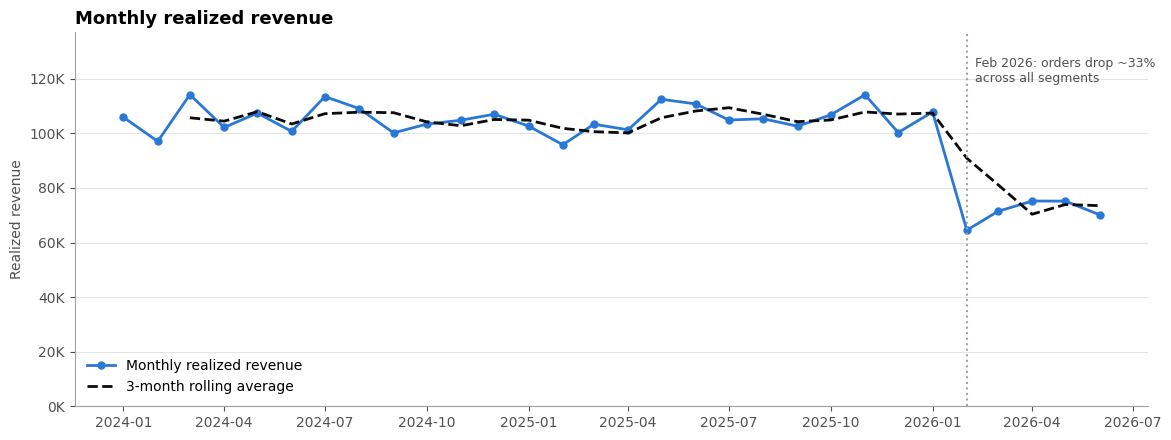

In [80]:
BREAK = pd.Timestamp('2026-02-01')

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly_rev.index, monthly_rev['Revenue'], color=BLUE, linewidth=2,
        marker='o', markersize=5, label='Monthly realized revenue')
ax.plot(monthly_rev.index, monthly_rev['Rolling3M'], color=INK, linewidth=2,
        linestyle='--', label='3-month rolling average')

# mark the February 2026 drop
ax.axvline(BREAK, color=GREY, linestyle=':', linewidth=1.5)
ax.annotate('Feb 2026: orders drop ~33%\nacross all segments',
            (BREAK, monthly_rev['Revenue'].max() * 1.12),
            textcoords='offset points', xytext=(6, 0), fontsize=9, color=MUTED, va='top')

ax.set_title('Monthly realized revenue')
ax.set_ylabel('Realized revenue')
ax.set_ylim(0, monthly_rev['Revenue'].max() * 1.2)
ax.yaxis.set_major_formatter(k_fmt)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

Revenue is fluctuating around 100-110k range since 2024 until it dropped significantly (by 40%) to 70k range from February 2026. AOV remains stable, which means that revenue dropped along with the number of orders and customers.  

**What drove the February 2026 drop?**

In [81]:
# Split the period at the break and compare averages
before = monthly_rev[monthly_rev.index < BREAK]
after = monthly_rev[monthly_rev.index >= BREAK]

drivers = pd.DataFrame({
    'Before (Jan 2024 - Jan 2026)': before[['Revenue', 'Orders', 'Customers', 'AOV']].mean(),
    'After (Feb - Jun 2026)': after[['Revenue', 'Orders', 'Customers', 'AOV']].mean(),
})
drivers['Change%'] = (drivers.iloc[:, 1] / drivers.iloc[:, 0] - 1) * 100
drivers.index = ['Avg monthly revenue', 'Avg monthly orders', 'Avg monthly customers', 'Avg order value']
display(drivers.round(1))

# Is the drop sudden? Compare daily orders in the month before vs the month after
daily_orders = realized.groupby('OrderDate').size()
jan = daily_orders['2026-01-01':'2026-01-31']
feb = daily_orders['2026-02-01':'2026-02-28']
print(f"Daily orders: Jan 2026 avg {jan.mean():.1f}, Feb 2026 avg {feb.mean():.1f} "
      f"(Mann-Whitney p = {stats.mannwhitneyu(jan, feb).pvalue:.4f})\n")

# Does the drop hit some groups harder? Compare each group's share of orders before vs after
realized['Period'] = np.where(realized['OrderDate'] >= BREAK, 'After', 'Before')
for col in ['Category', 'City', 'CustomerSegment', 'PaymentMethod']:
    mix = pd.crosstab(realized[col], realized['Period'], normalize='columns')[['Before', 'After']] * 100
    _, p_mix, _, _ = stats.chi2_contingency(pd.crosstab(realized[col], realized['Period']))
    print(f"{col}: largest share shift = {(mix['After'] - mix['Before']).abs().max():.1f} pts, "
          f"chi-square p = {p_mix:.3f} ({'No significant difference' if p_mix > 0.05 else 'Significant difference'})")

,Before (Jan 2024 - Jan 2026),After (Feb - Jun 2026),Change%
Avg monthly revenue,105347.2,71287.2,-32.3
Avg monthly orders,1506.6,1011.4,-32.9
Avg monthly customers,1399.2,964.2,-31.1
Avg order value,69.9,70.5,0.8


Daily orders: Jan 2026 avg 48.3, Feb 2026 avg 33.1 (Mann-Whitney p = 0.0000)

Category: largest share shift = 0.8 pts, chi-square p = 0.926 (No significant difference)
City: largest share shift = 0.9 pts, chi-square p = 0.546 (No significant difference)
CustomerSegment: largest share shift = 0.9 pts, chi-square p = 0.579 (No significant difference)
PaymentMethod: largest share shift = 1.0 pts, chi-square p = 0.711 (No significant difference)


**Finding:** From 1 February 2026, realized revenue fell ~32%, driven entirely by fewer orders and customers; average order value was unchanged. The drop is immediate (daily orders fell from ~48 to ~33 overnight) and identical across every category, city, segment and payment method; no group's share changed by more than 1 point.

A sudden, uniform drop like this usually points to an external or technical cause (e.g., a sales channel or data feed that stopped being recorded, a platform outage, or loss of an acquisition channel).

**Recommendation:** confirm with the data/engineering team whether this is a real sales decline before reporting it. Trend and seasonality below are measured on 2024-2025 only, so this event doesn't distort them.

**Long-term trend (2024–2025)**

In [82]:
# Trend on the two complete, stable years only
stable = monthly_rev[monthly_rev.index < '2026-01-01']
trend = stats.linregress(np.arange(len(stable)), stable['Revenue'])

print(f"Average monthly realized revenue (2024-2025): {stable['Revenue'].mean():,.0f}")
print(f"Trend 2024-2025: {trend.slope:+,.0f} per month, p-value = {trend.pvalue:.3f} -> "
      f"{'significant trend' if trend.pvalue < 0.05 else 'flat - no significant upward or downward trend'}")

# Year-over-year totals
yearly = stable.groupby(stable.index.year)[['Revenue', 'Orders']].sum()
yearly['AOV'] = yearly['Revenue'] / yearly['Orders']
yearly['Revenue_Growth%'] = yearly['Revenue'].pct_change() * 100
yearly.index.name = 'Year'
yearly.round(1)

Average monthly realized revenue (2024-2025): 105,243
Trend 2024-2025: +42 per month, p-value = 0.788 -> flat - no significant upward or downward trend


,Revenue,Orders,AOV,Revenue_Growth%
Year,,,,
2024,1265378.8,18000,70.3,<NA>
2025,1260448.9,18166,69.4,-0.4


In [83]:
# Did a growing customer base translate into more active buyers and revenue? (2024-2025)
base = realized[(realized['OrderDate'] < '2026-01-01') & ~realized['IsGuest']]
customer_growth = base.groupby('OrderMonth').agg(Revenue=('RealizedRevenue', 'sum'),
                                                 ActiveCustomers=('CustomerID', 'nunique'))

# Registered customers = everyone who signed up by the end of that month
signups = pd.to_datetime(customers['SignupDate'])
customer_growth['RegisteredCustomers'] = [
    (signups <= month + pd.offsets.MonthEnd(0)).sum() for month in customer_growth.index
]
customer_growth['ActiveShare(%'] = customer_growth['ActiveCustomers'] / customer_growth['RegisteredCustomers'] * 100
display(customer_growth.round(1))

active_trend = stats.linregress(np.arange(len(customer_growth)), customer_growth['ActiveCustomers'])

ci_low = active_trend.slope - 1.96 * active_trend.stderr
ci_high = active_trend.slope + 1.96 * active_trend.stderr
avg_active = customer_growth['ActiveCustomers'].mean()

print(f"Registered customers: {customer_growth['RegisteredCustomers'].iloc[0]:,} -> "
      f"{customer_growth['RegisteredCustomers'].iloc[-1]:,}")

print(f"Active customers per month: avg {avg_active:,.0f}, "
      f"trend {active_trend.slope:+.1f}/month (95% CI {ci_low:+.1f} to {ci_high:+.1f}), "
      f"p = {active_trend.pvalue:.2f} -> "
      f"{'significant change' if active_trend.pvalue < 0.05 else 'flat - no significant change'}")

,Revenue,ActiveCustomers,RegisteredCustomers,ActiveShare(%
OrderMonth,,,,
2024-01-01,105805.2,1395,3653,38.2
2024-02-01,97071.2,1271,3889,32.7
2024-03-01,114124.6,1468,4157,35.3
2024-04-01,102150.4,1367,4427,30.9
2024-05-01,107332.2,1397,4674,29.9
2024-06-01,100705.4,1386,4967,27.9
2024-07-01,113255.7,1424,5237,27.2
2024-08-01,108897.2,1445,5506,26.2
2024-09-01,100182.0,1326,5796,22.9


Registered customers: 3,653 -> 10,000
Active customers per month: avg 1,398, trend +1.4/month (95% CI -1.8 to +4.6), p = 0.41 -> flat - no significant change


Based on this analysis, registered customer seems to have significant growth from 2024 to 2025. However active customers does not seem to significantly increase. Despite the rapid growth in customer registration, the number of customers who actually made orders remain mostly the same. This means more customer sign ups does not lead to more sales.

**Seasonality chart (each year overlaid) & Statistical test**

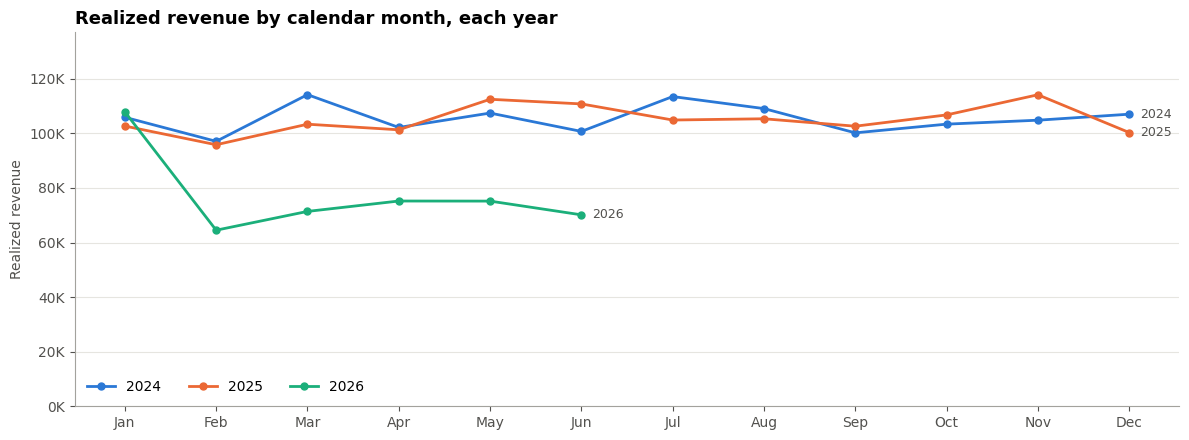

In [84]:
realized['Year'] = realized['OrderDate'].dt.year
realized['Month'] = realized['OrderDate'].dt.month
by_year_month = realized.pivot_table(index='Month', columns='Year',
                                     values='RealizedRevenue', aggfunc='sum')

fig, ax = plt.subplots(figsize=(12, 4.5))
for year in by_year_month.columns:
    s = by_year_month[year].dropna()
    ax.plot(s.index, s.values, color=YEAR_COLORS.get(year, GREY), linewidth=2,
            marker='o', markersize=5, label=str(year))
    ax.annotate(str(year), (s.index[-1], s.values[-1]), textcoords='offset points',
                xytext=(8, 0), va='center', fontsize=9, color=MUTED)   # direct label at line end

ax.set_xticks(range(1, 13), month_names)
ax.set_title('Realized revenue by calendar month, each year')
ax.set_ylabel('Realized revenue')
ax.set_ylim(0, by_year_month.max().max() * 1.2)
ax.yaxis.set_major_formatter(k_fmt)
ax.legend(loc='lower left', ncol=3)
plt.tight_layout()
plt.show()

Looking at the chart, monthly realized revenue does not seem to show any obvious/large trend.

Though each year trend shows an increase in March, slight decrease mid-year (May-June), then another increase at the end of the year (Oct - Nov).

Next action should be performing statistical test to see if the pattern above is significant/valid.

In [85]:
# Seasonal index: each calendar month's average revenue vs the overall monthly average
# (100 = an average month; 110 = 10% above average). Uses 2024-2025 only.
seasonal = stable.groupby(stable.index.month)['Revenue'].mean().to_frame('AvgRevenue')
seasonal['SeasonalIndex'] = seasonal['AvgRevenue'] / stable['Revenue'].mean() * 100
seasonal.index = month_names
display(seasonal.round(1))

# Test 1: does daily revenue differ by calendar month? (Kruskal-Wallis)
daily = (realized[realized['OrderDate'] < '2026-01-01']
         .groupby('OrderDate')['RealizedRevenue'].sum().to_frame('Revenue'))
daily['Month'] = daily.index.month
_, p_month = stats.kruskal(*[g['Revenue'].values for _, g in daily.groupby('Month')])
print(f"Daily revenue by month (2024-2025): Kruskal-Wallis p = {p_month:.3f} -> "
      f"{'seasonality present' if p_month < 0.05 else 'no significant monthly seasonality'}")

# Test 2: do 2024 and 2025 rise and fall in the same months? (real seasonality repeats each year)
corr = stats.spearmanr(by_year_month[2024], by_year_month[2025])
print(f"Same monthly pattern in 2024 and 2025? Spearman r = {corr.statistic:.2f}, p = {corr.pvalue:.3f}")

,AvgRevenue,SeasonalIndex
Jan,104279.6,99.1
Feb,96448.2,91.6
Mar,108763.5,103.3
Apr,101731.7,96.7
May,109959.3,104.5
Jun,105745.3,100.5
Jul,109180.8,103.7
Aug,107206.8,101.9
Sep,101399.6,96.3
Oct,105062.6,99.8


Daily revenue by month (2024-2025): Kruskal-Wallis p = 0.644 -> no significant monthly seasonality
Same monthly pattern in 2024 and 2025? Spearman r = 0.28, p = 0.379


Based on the statistical test result, it seems there are no monthly seasonality in revenue between 2024 & 2025. Furthermore, there seems to be no evidence that the two years share a pattern (corr p value > 0.05).

**Day-of-week pattern**

,AvgDailyRevenue,VsAverage%
Weekday,,
Monday,3291.1,-4.8
Tuesday,3287.2,-4.9
Wednesday,3186.4,-7.8
Thursday,3248.2,-6.0
Friday,3489.0,1.0
Saturday,3785.9,9.6
Sunday,3905.2,13.0


Daily revenue by weekday: Kruskal-Wallis p = 0.0000


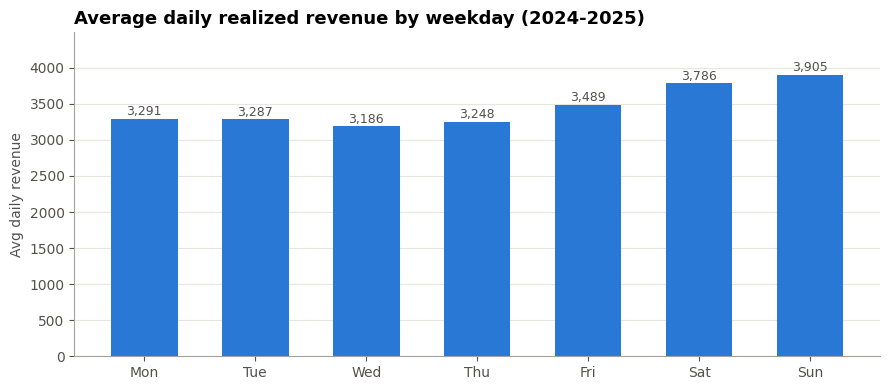

In [86]:
# Weekly pattern: average daily revenue by weekday (2024-2025)
daily['Weekday'] = daily.index.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

by_weekday = daily.groupby('Weekday')['Revenue'].mean().reindex(weekday_order).to_frame('AvgDailyRevenue')
by_weekday['VsAverage%'] = (by_weekday['AvgDailyRevenue'] / daily['Revenue'].mean() - 1) * 100
display(by_weekday.round(1))

_, p_wd = stats.kruskal(*[g['Revenue'].values for _, g in daily.groupby('Weekday')])
print(f"Daily revenue by weekday: Kruskal-Wallis p = {p_wd:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([d[:3] for d in weekday_order], by_weekday['AvgDailyRevenue'], color=BLUE, width=0.6)
for i, v in enumerate(by_weekday['AvgDailyRevenue']):
    ax.text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=9, color=MUTED)
ax.set_title('Average daily realized revenue by weekday (2024-2025)')
ax.set_ylabel('Avg daily revenue')
ax.set_ylim(0, by_weekday['AvgDailyRevenue'].max() * 1.15)
plt.tight_layout()
plt.show()

From the day-of-week analysis, it seems that revenue peaked in the weekend (~10% increase). Statistical test also show that the difference is statistically significant.

**Conclusion - Objective 1:**

1. **Trend:** Realized revenue was stable through 2024-2025 at ~105K per month (2025 was within 0.4% of 2024; no significant trend, p = 0.79). Registered customers nearly tripled over the same period (3,653 -> 10,000), but monthly active customers stayed flat at ~1,400 (p = 0.41), so new signups did not translate into more buyers. *Note:* signup dates are unreliable (28% of orders predate the signup date), so this comparison is indicative rather than conclusive.
2. **February 2026 break:** Revenue dropped ~32% overnight and stayed there, caused by fewer orders, not smaller baskets, and spread evenly across every segment. This needs verification with the data owner before being treated as a real decline.
3. **Monthly seasonality:** None detected. Month-to-month differences are random noise (p = 0.64), and the two years don't share a monthly pattern, so there is no peak season to plan inventory or campaigns around.
4. **Weekly pattern:** Revenue is 10-13% higher on Saturday and Sunday and lowest mid-week (p < 0.001). **Recommendation:** schedule promotions and email campaigns for Friday-Sunday when customers are most active, and use mid-week for lower-cost re-engagement offers.

## Sales Driver (Product)

**Category summary & chart (order share vs revenue share)**

In [87]:
ORANGE = '#eb6834'   # second series color (add to the style colors from Objective 1)

cat_mix = (realized.groupby('Category', observed=True)
           .agg(Orders=('OrderID', 'size'),
                Units=('Quantity', 'sum'),
                Revenue=('RealizedRevenue', 'sum'),
                Products=('ProductID', 'nunique')))
cat_mix['OrderShare%'] = cat_mix['Orders'] / cat_mix['Orders'].sum() * 100
cat_mix['RevenueShare%'] = cat_mix['Revenue'] / cat_mix['Revenue'].sum() * 100
cat_mix['RevenuePerOrder'] = cat_mix['Revenue'] / cat_mix['Orders']
# Value index: revenue share / order share. Above 1 = earns more than its share of orders
cat_mix['RevenueToOrderRatio'] = cat_mix['RevenueShare%'] / cat_mix['OrderShare%']
cat_mix = cat_mix.sort_values('Revenue', ascending=False)
cat_mix.round(2)

,Orders,Units,Revenue,Products,OrderShare%,RevenueShare%,RevenuePerOrder,ValueIndex
Category,,,,,,,,
Electronics,15445,28658,1511908.8,9,36.15,50.56,97.89,1.4
Accessories,15769,30013,482419.55,5,36.91,16.13,30.59,0.44
Home Office,2728,5168,389920.2,2,6.39,13.04,142.93,2.04
Wearables,2666,4983,375041.75,2,6.24,12.54,140.68,2.01
Gaming,1453,2762,173359.2,1,3.40,5.8,119.31,1.7
Stationery,4660,8858,57465.45,1,10.91,1.92,12.33,0.18


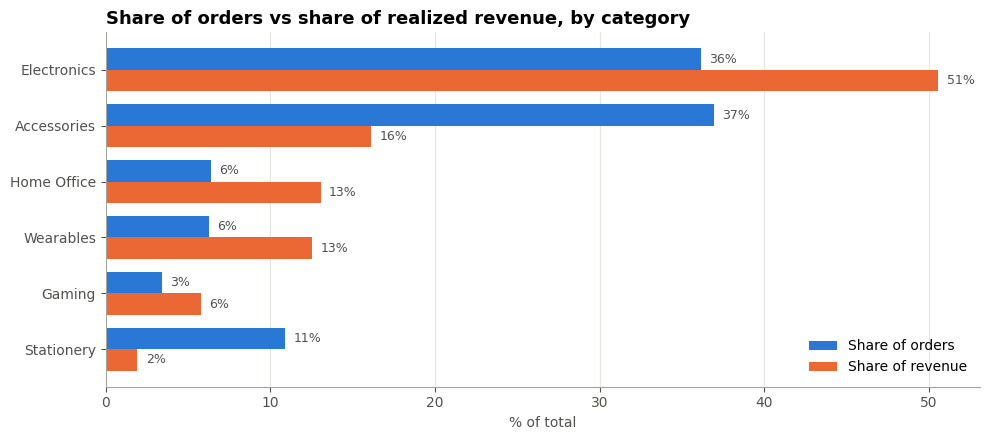

In [88]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = cat_mix.sort_values('RevenueShare%').index   # largest at the top
y = np.arange(len(order))
h = 0.38

ax.barh(y + h/2, cat_mix.loc[order, 'OrderShare%'], height=h, color=BLUE, label='Share of orders')
ax.barh(y - h/2, cat_mix.loc[order, 'RevenueShare%'], height=h, color=ORANGE, label='Share of revenue')
for i, cat in enumerate(order):
    ax.text(cat_mix.loc[cat, 'OrderShare%'] + 0.5, i + h/2, f"{cat_mix.loc[cat, 'OrderShare%']:.0f}%",
            va='center', fontsize=9, color=MUTED)
    ax.text(cat_mix.loc[cat, 'RevenueShare%'] + 0.5, i - h/2, f"{cat_mix.loc[cat, 'RevenueShare%']:.0f}%",
            va='center', fontsize=9, color=MUTED)

ax.set_yticks(y, order)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('% of total')
ax.set_title('Share of orders vs share of realized revenue, by category')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

There are 3 main findings from this analysis:


1.   More than half (51%) of the revenue comes from Electronics Products sales taking up 36% of all the orders (second highest out of all product categories). This means that electronic products are the sales & revenue driver (most popular product category as well as the one that generates the most revenue).
2.   Despite having the highest number of order/sales (37%), Accessories does not generate much revenue (16%). This is expected as accessories generally have lower price.
3.   Looking at the valueindex, Home office and wearable products seem to generate a considerably high revenue for the business despite having lower sales (13% revenue share against 6% sales/orders). This indicate that these products have good revenue-making potential if the business can boost its sales.     

**Product ranking, ABC analysis, and Volume vs value scatter plot**

In [89]:
prod_mix = (realized.groupby(['ProductName', 'Category'], observed=True)
            .agg(UnitPrice=('UnitPrice', 'first'),
                 Orders=('OrderID', 'size'),
                 Units=('Quantity', 'sum'),
                 Revenue=('RealizedRevenue', 'sum'))
            .reset_index()
            .sort_values('Revenue', ascending=False))
prod_mix['OrderShare%'] = prod_mix['Orders'] / prod_mix['Orders'].sum() * 100
prod_mix['RevenueShare%'] = prod_mix['Revenue'] / prod_mix['Revenue'].sum() * 100
prod_mix['CumRevenueShare%'] = prod_mix['RevenueShare%'].cumsum()
prod_mix['UnitsPerOrder'] = prod_mix['Units'] / prod_mix['Orders']

# ABC classification: A = products making up the first 70% of revenue, B = next 20%, C = last 10%
prev_cum = prod_mix['CumRevenueShare%'] - prod_mix['RevenueShare%']
prod_mix['RevenueTier'] = np.select([prev_cum < 70, prev_cum < 90], ['A', 'B'], default='C')

prod_mix = prod_mix.reset_index(drop=True)
prod_mix.index = prod_mix.index + 1   # rank starting at 1
display(prod_mix.round(2))

abc = prod_mix.groupby('RevenueTier').agg(Products=('ProductName', 'size'),
                                  OrderShare=('OrderShare%', 'sum'),
                                  RevenueShare=('RevenueShare%', 'sum'))
abc.round(1)

,ProductName,Category,UnitPrice,Orders,Units,Revenue,OrderShare%,RevenueShare%,CumRevenueShare%,UnitsPerOrder,ABC
1,Headphones,Electronics,75.0,2246,4206,292207.5,5.26,9.77,9.77,1.87,A
2,Office Chair,Home Office,180.0,906,1733,288261.0,2.12,9.64,19.41,1.91,A
3,Tablet,Electronics,260.0,552,1027,243789.0,1.29,8.15,27.57,1.86,A
4,Smart Watch,Wearables,120.0,1072,2023,223998.0,2.51,7.49,35.06,1.89,A
5,Microphone,Electronics,85.0,1360,2586,203349.75,3.18,6.8,41.86,1.9,A
6,Mechanical Keyboard,Electronics,62.0,1843,3391,194689.3,4.31,6.51,48.37,1.84,A
7,Bluetooth Speaker,Electronics,58.0,1834,3433,184164.5,4.29,6.16,54.53,1.87,A
8,Gaming Controller,Gaming,68.0,1453,2762,173359.2,3.40,5.8,60.33,1.9,A
9,Power Bank,Electronics,35.0,2573,4796,155268.75,6.02,5.19,65.52,1.86,A
10,Fitness Band,Wearables,55.0,1594,2960,151043.75,3.73,5.05,70.57,1.86,A


,Products,OrderShare,RevenueShare
ABC,,,
A,10,36.1,70.6
B,5,27.4,19.6
C,5,36.5,9.9


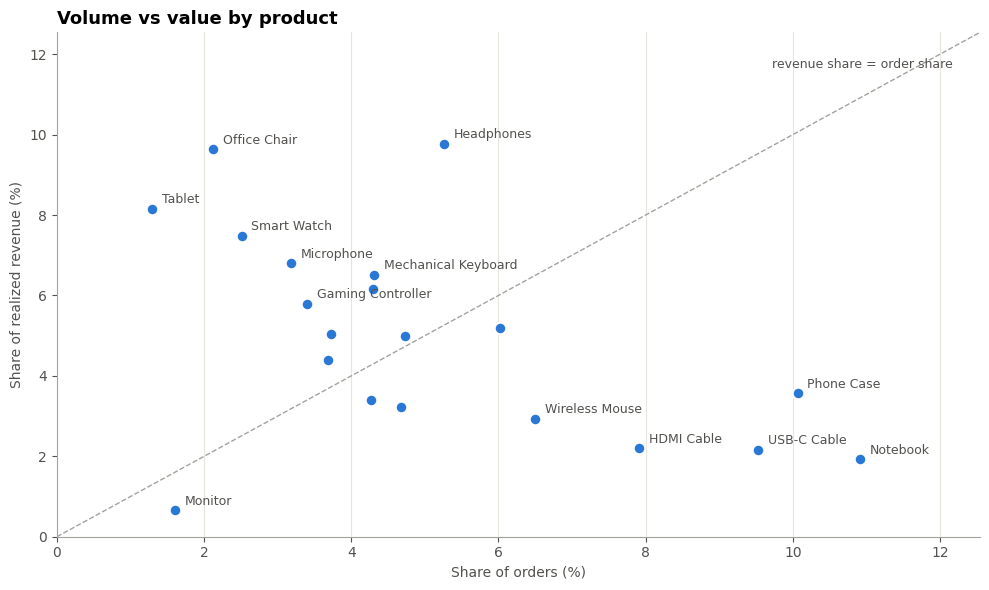

In [90]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(prod_mix['OrderShare%'], prod_mix['RevenueShare%'], s=70, color=BLUE,
           edgecolor='white', linewidth=1.5, zorder=3)

# diagonal: products on this line earn exactly their share of orders
lim = max(prod_mix['OrderShare%'].max(), prod_mix['RevenueShare%'].max()) * 1.15
ax.plot([0, lim], [0, lim], color=GREY, linestyle='--', linewidth=1, zorder=2)
ax.text(lim * 0.97, lim * 0.93, 'revenue share = order share', ha='right', fontsize=9, color=MUTED)

# label only products far from the diagonal, the biggest earners, and the Monitor anomaly
gap = (prod_mix['RevenueShare%'] - prod_mix['OrderShare%']).abs()
to_label = prod_mix[(gap > 2) | (prod_mix['RevenueShare%'] > 8) | (prod_mix['ProductName'] == 'Monitor')]
for _, r in to_label.iterrows():
    ax.annotate(r['ProductName'], (r['OrderShare%'], r['RevenueShare%']),
                textcoords='offset points', xytext=(7, 4), fontsize=9, color=MUTED)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.grid(axis='both')
ax.set_xlabel('Share of orders (%)')
ax.set_ylabel('Share of realized revenue (%)')
ax.set_title('Volume vs value by product')
plt.tight_layout()
plt.show()

For a more detailed analysis, we look at revenue and no. of orders by the product itself.

Findings:


*   In general, lower priced items lead to higher sales (which is as expected). However, there's a few products that have a relatively high sales while still making high revenues for the business such as headphones, keyboard, and power bank.
*   From the ABC analysis, the top 10 (A-rank) products already generated more than 70% of the revenue for the business with less than 10% of revenue coming from the bottom 5 products (rank C). The top 10 products are mostly in electronics category although the second product in this category (office chair) is a Home Office product.
* There are no significant difference in the number of product purchased per orders across all products and product categories (1-2 product bought/order).



**Does price affect demand?**

In [91]:
# Do expensive products get fewer orders, or fewer units per order?
rho_orders = stats.spearmanr(prod_mix['UnitPrice'], prod_mix['Orders'])
rho_units = stats.spearmanr(prod_mix['UnitPrice'], prod_mix['UnitsPerOrder'])
print(f"Price vs number of orders:  Spearman r = {rho_orders.statistic:.2f}, p = {rho_orders.pvalue:.3f}")
print(f"Price vs units per order:   Spearman r = {rho_units.statistic:.2f}, p = {rho_units.pvalue:.3f}")

Price vs number of orders:  Spearman r = -0.76, p = 0.000
Price vs units per order:   Spearman r = -0.18, p = 0.439


Result from correlation test shows that price has a significant negative correlation with number of orders. This means that higher price leads to lower sales or demand. However, the product price does not have significant impact on the number of product (quantity) purchased each order. Although there's a negative correlation between price and units/order it is not statistically significant.

**Is the mix stable over time?**

In [95]:
# Compare category revenue mix in the two complete years
stable_years = realized[realized['OrderDate'].dt.year.isin([2024, 2025])].copy()
stable_years['Year'] = stable_years['OrderDate'].dt.year

mix_by_year = pd.crosstab(stable_years['Category'], stable_years['Year'],
                          values=stable_years['RealizedRevenue'], aggfunc='sum',
                          normalize='columns') * 100
display(mix_by_year.round(1))

mix_by_year2 = pd.crosstab(stable_years['Category'], stable_years['Year'],
                          values=stable_years['OrderID'], aggfunc='size',
                          normalize='columns') * 100
display(mix_by_year2.round(1))

_, p_mix, _, _ = stats.chi2_contingency(pd.crosstab(stable_years['Category'], stable_years['Year']))
print(f"Did the category mix of orders change between 2024 and 2025? chi-square p = {p_mix:.3f}")

Year,2024,2025
Category,,
Accessories,16.2,16.4
Electronics,49.9,50.8
Gaming,5.9,5.8
Home Office,13.6,12.6
Stationery,1.9,2.0
Wearables,12.6,12.5


Year,2024,2025
Category,,
Accessories,36.9,37.2
Electronics,36.1,36.0
Gaming,3.5,3.3
Home Office,6.6,6.2
Stationery,10.7,11.0
Wearables,6.2,6.3


Did the category mix of orders change between 2024 and 2025? chi-square p = 0.531


From the tests above, we can conclude that mix of orders does not experience significant change between 2024 and 2025. This means that the revenue generated (%) per product category remains mostly the same from 2024-2025 and no specific product become more/less popular over said period.

**Sanity check (unit price, order check per product)**

In [94]:
# Data quality check: Monitor's price and quantity pattern vs other products
qty_range = (finaldf.groupby('ProductName', observed=True)['Quantity']
             .agg(['min', 'max', 'mean']).join(products.set_index('ProductName')['UnitPrice']))
display(qty_range.sort_values('UnitPrice').round(2))

,min,max,mean,UnitPrice
ProductName,,,,
Notebook,1,5,1.9,7.0
USB-C Cable,1,5,1.91,9.0
HDMI Cable,1,5,1.9,11.0
Phone Case,1,5,1.91,14.0
Wireless Mouse,1,5,1.89,18.0
Monitor,1,3,1.48,21.0
Laptop Stand,1,5,1.86,28.0
Desk Lamp,1,5,1.89,32.0
Power Bank,1,5,1.87,35.0


Result: need to reconfirm monitor price

**Conclusion - Objective 2:**

1. **Electronics brings in the most revenue:** 51% of realized revenue from 36% of orders. Accessories brings similar order volume (37%) but only 16% of revenue.
2. **Revenue is concentrated:** 10 of 20 products (class A) generate 71% of revenue from 36% of orders. Headphones, Office Chair and Tablet alone make up 28%. Tablet reaches the top 3 with just 1.3% of orders.
3. **Low-price items drive traffic (high # of orders), not revenue:** the 5 class-C products (cables, notebook, mouse, monitor) take 37% of orders but earn 10% of revenue. Cheaper products get far more orders (r = -0.76), but customers buy the same number of units (~1.9) regardless of price.
4. **The mix is stable:** category shares did not change between 2024 and 2025 (p = 0.53).
5. **Data quality flag:** Monitor is priced at 21, below a desk lamp, and its quantity never exceeds 3 while all other products go up to 5. Its price is likely incorrect in the product table, so its revenue is probably understated. Verify with the product team.

**Recommendations:**
- **Protect class A products:** prioritise stock availability, placement and marketing spend on the 10 products that earn 71% of revenue.
- **Use class C items as basket builders:** cables, cases and notebooks are high-traffic, low-value. Bundle them with high-value items (e.g., "Tablet + case + USB-C cable") or show them as add-ons at checkout to raise revenue per order.
- **Grow high-value niches:** Home Office and Wearables products earn twice their share of orders (value index ~2.0) and are worth targeted campaigns to increase volume.
- **Profitability Analysis:** Ask the data team if they have data on cost of goods sold. This will allow analyst to perform analysis on profit, not only revenue/sales. Profitability analysis will give clearer view on which product is truly profitable and gain insight on how to optimize profit.

## Revenue Leakage

In [72]:
# Revenue leakage: potential vs realized revenue
# (orders with missing quantity are excluded because revenue can't be calculated)
valid = finaldf[~finaldf['QuantityMissing']]

potential = valid['NetRevenue'].sum()
realized = valid['RealizedRevenue'].sum()
print(f"Potential net revenue : {potential:,.0f}")
print(f"Realized net revenue  : {realized:,.0f}")
print(f"Revenue leakage       : {potential - realized:,.0f} ({1 - realized / potential:.1%})")

# Where does the leakage come from?
leak = (
    valid.assign(Outcome=np.where(
        valid['IsRealized'], 'Realized',
        valid['Status'].astype(str) + ' / ' + valid['PaymentStatus'].astype(str)))
    .groupby('Outcome')['NetRevenue'].agg(['count', 'sum'])
    .rename(columns={'count': 'Orders', 'sum': 'NetRevenue'})
    .sort_values('NetRevenue', ascending=False)
)
leak['ShareOfPotential'] = (leak['NetRevenue'] / potential * 100).round(1)
leak

Potential net revenue : 3,496,162
Realized net revenue  : 2,991,795
Revenue leakage       : 504,367 (14.4%)


,Orders,NetRevenue,ShareOfPotential
Outcome,,,
Realized,42754,2991794.85,85.6
Cancelled / Paid,2300,172099.5,4.9
Completed / Failed,1752,117906.85,3.4
Completed / Refunded,1394,100986.0,2.9
Returned / Paid,1411,96266.4,2.8
Cancelled / Failed,93,6147.45,0.2
Returned / Failed,79,4659.4,0.1
Cancelled / Refunded,71,3611.75,0.1
Returned / Refunded,41,2689.65,0.1


Potential revenue is about 3.50M and realized revenue about 2.99M, so leakage is about 0.50M (14.4%). The biggest single leak is cancelled orders marked as paid: 172K, or 4.9% of potential revenue.


Next action would be to split the 504k leakage by type.



*   Paid payment status but cancelled/returned status  might mean that the money was taken but the order didn't stand. This isn't lost revenue: it's money the business may owe customers.
*   Completed status but failed payment status means that goods were shipped without payment. This is a real loss.
*   Completed status but refunded payment status means that the customer kept the goods and got their money back.
*   Other status pairs, indicates that the process worked as it should (cancelled/returned and payment refunded/failed).



In [73]:
# Classify each leaked order by what actually went wrong
valid = finaldf[~finaldf['QuantityMissing']].copy()
valid['LeakedRevenue'] = valid['NetRevenue'] - valid['RealizedRevenue']

leak_type = {
    ('Cancelled', 'Paid'):     'Owed to customer (refund not issued)',
    ('Returned',  'Paid'):     'Owed to customer (refund not issued)',
    ('Completed', 'Failed'):   'Not collected (shipped without payment)',
    ('Completed', 'Refunded'): 'Refunded after delivery',
}
valid['LeakType'] = [
    'Realized' if r else leak_type.get((s, ps), 'Expected loss (cancel/return processed correctly)')
    for r, s, ps in zip(valid['IsRealized'], valid['Status'], valid['PaymentStatus'])
]

leak_summary = (valid[~valid['IsRealized']]
                .groupby('LeakType')
                .agg(Orders=('OrderID', 'size'), LeakedRevenue=('LeakedRevenue', 'sum'))
                .sort_values('LeakedRevenue', ascending=False))
leak_summary['ShareOfLeak(%)'] = (leak_summary['LeakedRevenue'] / leak_summary['LeakedRevenue'].sum() * 100).round(1)
leak_summary

,Orders,LeakedRevenue,ShareOfLeak(%)
LeakType,,,
Owed to customer (refund not issued),3711,268365.9,53.2
Not collected (shipped without payment),1752,117906.85,23.4
Refunded after delivery,1394,100986.0,20.0
Expected loss (cancel/return processed correctly),284,17108.25,3.4


Based on the result, the majority of leakage is cancelled-but-paid orders. This reframes the biggest problem. The cancelled-but-paid orders aren't revenue the business failed to earn. They're likely refunds that were never issued, which is a customer-trust and possibly a legal risk rather than a sales problem.

As a solution, assign to finance team to audit the 3,711 "owed to customer" orders now. Confirm whether refunds were actually paid. If they were, fix the status records. If not, issue them before customers complain or charge back.

Recommended actions for other leakage type:


1. **Operations**: require confirmed payment before dispatch. This targets the approximately 118K shipped without payment. Retry failed payments or send them to collections.

2. **Customer service**: require a reason code for every refund on a completed order. That reveals whether the 1,394 refunded orders is damaged goods, items not received, or possible refund abuse.

3. **IT/Data**: run a daily automated reconciliation report that flags any order whose order status and payment status disagree. Assign an owner for the exception queue, and set a KPI such as "status mismatch rate below 1%", down from 13.9% today.

**Is leakage concentrated anywhere?**

In [74]:
# Leakage rate by dimension, with a chi-square test for whether differences are real
def leakage_by(col):
    g = (valid.groupby(col, observed=True)
         .agg(Orders=('OrderID', 'size'), Potential=('NetRevenue', 'sum'), Leaked=('LeakedRevenue', 'sum')))
    g['LeakRate%'] = (g['Leaked'] / g['Potential'] * 100).round(1)
    _, p_value, _, _ = stats.chi2_contingency(pd.crosstab(valid[col], valid['IsRealized']))
    print(f"\n{col}: chi-square p-value = {p_value:.3f} "
          f"({'differences are significant' if p_value < 0.05 else 'no significant difference'})")
    display(g.sort_values('LeakRate%', ascending=False))

for col in ['PaymentMethod', 'Category', 'CustomerSegment', 'City', 'Discount']:
    leakage_by(col)


PaymentMethod: chi-square p-value = 0.359 (no significant difference)


,Orders,Potential,Leaked,LeakRate%
PaymentMethod,,,,
Wallet,8762,613181.3,93383.1,15.2
CardToCard,11924,843714.85,121651.2,14.4
Gateway,23768,1659432.85,237214.65,14.3
Cash,4992,347889.6,47931.1,13.8
Unknown,449,31943.25,4186.95,13.1



Category: chi-square p-value = 0.420 (no significant difference)


,Orders,Potential,Leaked,LeakRate%
Category,,,,
Electronics,18016,1777044.8,264375.5,14.9
Stationery,5495,67704.35,10095.05,14.9
Accessories,18440,561415.65,78661.85,14.0
Wearables,3092,436391.25,61005.0,14.0
Gaming,1685,201419.4,27992.2,13.9
Home Office,3167,452186.4,62237.4,13.8



CustomerSegment: chi-square p-value = 0.493 (no significant difference)


,Orders,Potential,Leaked,LeakRate%
CustomerSegment,,,,
VIP,4945,338864.8,50247.35,14.8
Regular,27673,1946145.15,285810.25,14.7
New,17247,1209160.8,168053.45,13.9
Guest,30,1991.1,255.95,12.9



City: chi-square p-value = 0.873 (no significant difference)


,Orders,Potential,Leaked,LeakRate%
City,,,,
Rasht,2859,205969.2,35119.75,17.1
Ahvaz,2925,211324.2,33448.45,15.8
Kerman,2466,175209.4,26747.55,15.3
Karaj,4969,350638.1,52652.25,15.0
Tehran,14006,964495.0,141112.05,14.6
Unknown,633,47117.6,6863.4,14.6
Mashhad,6220,438062.7,61263.7,14.0
Isfahan,4915,334695.15,46829.65,14.0
Qom,2373,163150.8,22123.35,13.6



Discount: chi-square p-value = 0.277 (no significant difference)


,Orders,Potential,Leaked,LeakRate%
Discount,,,,
0.10,9955,684431.1,101179.8,14.8
0.00,17587,1316744.0,192373.0,14.6
0.20,3571,220121.6,31959.2,14.5
0.05,10841,779889.2,111352.35,14.3
0.15,5999,386886.85,53595.05,13.9
0.30,1942,108089.1,13907.6,12.9


Difference test in leakrate by Payment method, category, customer segment, and discount level shows that every leakage rate falls between 13% and 15%. None of the differences are statistically significant (all chi-square p-values above 0.27).

Meanwhile, difference test by city indicate that Rasht looks worst at 17.1% and Shiraz best at 12.6%. However, the p-value is 0.83, so that gap is random noise.

**Is it getting worse? (control chart)**

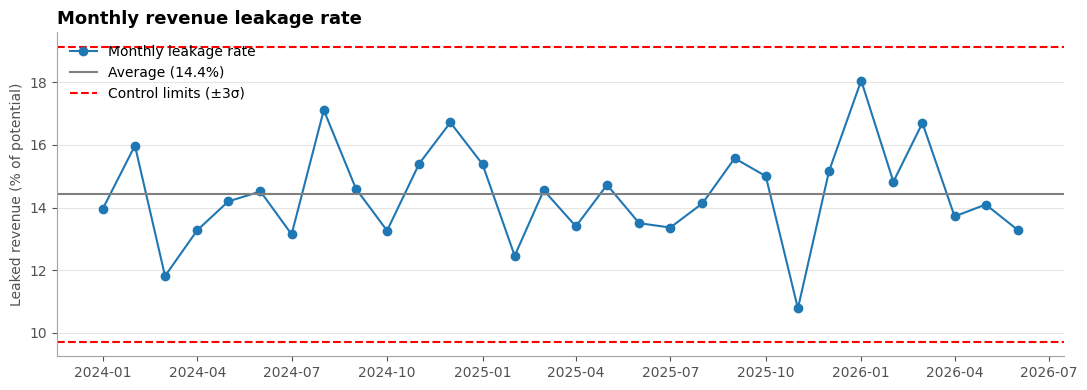

Months outside control limits: 0


In [75]:
# Monthly leakage rate with ±3 standard deviation control limits
monthly = (valid.dropna(subset=['OrderMonth'])
           .groupby('OrderMonth')
           .agg(Potential=('NetRevenue', 'sum'), Leaked=('LeakedRevenue', 'sum')))
monthly['LeakRate%'] = monthly['Leaked'] / monthly['Potential'] * 100

mean, sd = monthly['LeakRate%'].mean(), monthly['LeakRate%'].std()
ucl, lcl = mean + 3 * sd, mean - 3 * sd

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly['LeakRate%'], marker='o', label='Monthly leakage rate')
ax.axhline(mean, color='grey', label=f'Average ({mean:.1f}%)')
ax.axhline(ucl, color='red', linestyle='--', label='Control limits (±3σ)')
ax.axhline(lcl, color='red', linestyle='--')
ax.set_ylabel('Leaked revenue (% of potential)')
ax.set_title('Monthly revenue leakage rate')
ax.legend()
plt.tight_layout()
plt.show()

out_of_control = monthly[(monthly['LeakRate%'] > ucl) | (monthly['LeakRate%'] < lcl)]
print(f"Months outside control limits: {len(out_of_control)}")

Over time no month falls outside the statistical control limits. Leakage is stable at about 14%, not getting worse.

**Do customers come back after a bad order?**

In [76]:
# Repurchase within 180 days after a realized vs leaked order
cust = (valid[(~valid['IsGuest']) & valid['OrderDate'].notna()]
        .sort_values(['CustomerID', 'OrderDate', 'OrderID']).copy())
cust['DaysToNextOrder'] = (cust.groupby('CustomerID')['OrderDate'].shift(-1) - cust['OrderDate']).dt.days

# only use orders with a full 180 days of follow-up available
cutoff = cust['OrderDate'].max() - pd.Timedelta(days=180)
window = cust[cust['OrderDate'] <= cutoff].copy()
window['Rebought180'] = window['DaysToNextOrder'] <= 180

rebuy = (window.groupby('LeakType')
         .agg(Orders=('OrderID', 'size'),
              RebuyRate180=('Rebought180', 'mean'),
              MedianDaysToNext=('DaysToNextOrder', 'median')))
rebuy['RebuyRate180'] = (rebuy['RebuyRate180'] * 100).round(1)
display(rebuy)

_, p_value, _, _ = stats.chi2_contingency(pd.crosstab(window['IsRealized'], window['Rebought180']))
print(f"Realized vs leaked orders, 180-day repurchase: chi-square p-value = {p_value:.3f}")

,Orders,RebuyRate180,MedianDaysToNext
LeakType,,,
Expected loss (cancel/return processed correctly),242,62.8,101.5
Not collected (shipped without payment),1479,64.3,100.0
Owed to customer (refund not issued),3096,63.7,101.0
Realized,36181,63.8,104.0
Refunded after delivery,1188,63.5,103.0


Realized vs leaked orders, 180-day repurchase: chi-square p-value = 0.924


From table above, customers whose order leaked bought again within 180 days at the same rate (about 64%) as customers whose order went through (p = 0.92).

**Repeat-offender check: do leaked orders cluster in certain customers, or are they random?**


In [77]:
# 1. Count orders and leaked orders per customer (exclude guest orders and orders without a date)
cust = valid[(~valid['IsGuest']) & valid['OrderDate'].notna()]
per_customer = (cust.groupby('CustomerID')
                .agg(TotalOrders=('OrderID', 'size'),
                     LeakedOrders=('IsRealized', lambda s: (~s).sum())))

# 2. Overall chance that any single order leaks
leak_rate = 1 - cust['IsRealized'].mean()
print(f"Overall order leak rate: {leak_rate:.1%}")

# 3. Observed: customers with 3 or more leaked orders
observed = (per_customer['LeakedOrders'] >= 3).sum()

# 4. Expected by chance: if every order leaks independently with the same probability,
#    a customer with n orders has a Binomial(n, leak_rate) number of leaked orders.
#    P(3 or more leaked) = 1 - P(2 or fewer) = 1 - binom.cdf(2, n, leak_rate)
per_customer['P_3plus'] = 1 - stats.binom.cdf(2, per_customer['TotalOrders'], leak_rate)
expected = per_customer['P_3plus'].sum()

print(f"Customers with 3+ leaked orders - observed: {observed}, expected by chance: {expected:.1f}")

# 5. Full distribution: observed vs expected number of customers with 0, 1, 2, 3, 4+ leaked orders
rows = []
for k in [0, 1, 2, 3]:
    rows.append({'LeakedOrders': str(k),
                 'Observed': (per_customer['LeakedOrders'] == k).sum(),
                 'Expected': stats.binom.pmf(k, per_customer['TotalOrders'], leak_rate).sum()})
rows.append({'LeakedOrders': '4+',
             'Observed': (per_customer['LeakedOrders'] >= 4).sum(),
             'Expected': (1 - stats.binom.cdf(3, per_customer['TotalOrders'], leak_rate)).sum()})
dist = pd.DataFrame(rows).set_index('LeakedOrders')
dist['Expected'] = dist['Expected'].round(1)
display(dist)

# 6. Goodness-of-fit test: does the observed distribution differ from pure chance?
#    ddof=1 because leak_rate was estimated from the same data
f_exp = dist['Expected'] * dist['Observed'].sum() / dist['Expected'].sum()   # rescale so totals match exactly
chi2, p_value = stats.chisquare(dist['Observed'], f_exp=f_exp, ddof=1)
print(f"Chi-square goodness-of-fit p-value = {p_value:.3f} "
      f"({'leaked orders cluster in certain customers' if p_value < 0.05 else 'consistent with random chance - no repeat-offender cluster'})")

Overall order leak rate: 14.3%
Customers with 3+ leaked orders - observed: 362, expected by chance: 356.7


,Observed,Expected
LeakedOrders,,
0,4827,4835.1
1,3518,3501.0
2,1232,1246.2
3,308,295.7
4+,54,61.0


Chi-square goodness-of-fit p-value = 0.666 (consistent with random chance - no repeat-offender cluster)


The number of leaked orders per customer closely matches what we'd expect if every order had the same 14.3% chance of leaking (goodness-of-fit p = 0.67). Customers with 3+ leaked orders (362) are no more common than chance predicts (~357). There is no evidence of repeat refund abuse by specific customers. From here we can assume that leakage is a process issue, not a customer-behaviour issue.

**Conclusion - Objective 3:**

1. **14.4% of potential revenue is lost** (504K of 3.50M).
2. **Most of it is not lost sales but unresolved refunds and payments:**
   - 53% are refunds owed to customers: orders cancelled or returned but still marked as paid.
   - 23% are payments not collected: orders delivered but the payment failed.
   - 20% were refunded after delivery.
   - Only 3% are normal cancellations and returns handled correctly.
3. **The loss is spread evenly:** the loss rate is the same across payment methods, categories, segments, cities and discount levels (all p > 0.27). It has been stable over time (no month outside the control limits).
4. **Customers are not put off:** customers buy again within 180 days at the same rate after an unsuccessful order as after a successful one (~64%, p = 0.92).
5. **No repeat offenders:** the number of unsuccessful orders per customer matches what random chance predicts (p = 0.66).

Because the loss is the same everywhere, the cause is a **process problem**: the order system and the payment system are not kept in sync. It is not caused by a particular product, customer group or payment method.

**Recommended actions:**
1. **Finance:** check the orders where a refund is owed and confirm whether refunds were paid; correct the records or issue the refunds.
2. **Operations:** confirm payment before dispatching orders, to stop delivering orders that are never paid for.
3. **Customer service:** record a reason for every refund after delivery.
4. **IT/Data:** run a daily report of orders with a status mismatch, assign an owner, and track the mismatch rate as a KPI (target below 1%, currently 14%).

## Customer Value

**Build a **customer table** (one row per customer) from successful orders.**

In [130]:
# One row per customer: what each customer has bought (realized orders only, guest orders excluded)
reference_date = realized['OrderDate'].max() + pd.Timedelta(days=1)   # the day after the last order in the data
buyer_orders = realized[~realized['IsGuest']]


customer_table = (buyer_orders.groupby('CustomerID')
                  .agg(Orders=('OrderID', 'size'),
                       Revenue=('RealizedRevenue', 'sum'),
                       FirstOrder=('OrderDate', 'min'),
                       LastOrder=('OrderDate', 'max'),
                       CategoriesBought=('Category', 'nunique')))
customer_table['AvgRevenuePerOrder'] = customer_table['Revenue'] / customer_table['Orders']
customer_table['DaysSinceLastOrder'] = (reference_date - customer_table['LastOrder']).dt.days
# average gap between orders (only for customers with 2+ orders)
customer_table['AvgDaysBetweenOrders'] = ((customer_table['LastOrder'] - customer_table['FirstOrder']).dt.days
                                          / (customer_table['Orders'] - 1)).where(customer_table['Orders'] > 1)


# Add the customer profile (every registered customer, including those who never bought)
profile = (customers.set_index('CustomerID')[['CustomerSegment', 'Age', 'Age_Group', 'City_cleaned', 'SignupDate']]
           .rename(columns={'City_cleaned': 'City'}))
customer_table = profile.join(customer_table, how='left')
customer_table['Orders'] = customer_table['Orders'].fillna(0).astype(int)
customer_table['Revenue'] = customer_table['Revenue'].fillna(0).astype(float)
customer_table['HasBought'] = customer_table['Orders'] > 0


buyers = customer_table[customer_table['HasBought']].copy()
print(f"Registered customers: {len(customer_table):,}")
print(f"Buyers (at least one realized order): {len(buyers):,} ({customer_table['HasBought'].mean():.1%})")
print(f"Avg orders per buyer: {buyers['Orders'].mean():.1f}, avg revenue per buyer: {buyers['Revenue'].mean():,.0f}")
customer_table.head()


Registered customers: 10,000
Buyers (at least one realized order): 9,858 (98.6%)
Avg orders per buyer: 4.3, avg revenue per buyer: 303


,CustomerSegment,Age,Age_Group,City,SignupDate,Orders,Revenue,FirstOrder,LastOrder,CategoriesBought,AvgRevenuePerOrder,DaysSinceLastOrder,AvgDaysBetweenOrders,HasBought
CustomerID,,,,,,,,,,,,,,
100001,Regular,22.0,18-25,Tehran,2023-09-11,7,908.75,2024-05-30,2026-05-29,5.0,129.821429,33.0,121.500000,True
100002,VIP,55.0,51-65,Tabriz,2024-01-16,7,390.80,2024-04-24,2025-11-22,5.0,55.828571,221.0,96.166667,True
100003,New,49.0,36-50,Karaj,2025-07-31,4,309.30,2024-01-20,2025-11-03,3.0,77.325,240.0,217.666667,True
100004,New,39.0,36-50,Tehran,2023-04-23,6,210.10,2024-07-21,2026-03-15,2.0,35.016667,108.0,120.400000,True
100005,Regular,38.0,36-50,Tehran,2023-04-29,4,357.45,2024-04-07,2025-12-30,2.0,89.3625,183.0,210.666667,True


**Is signup date related to number of orders?**

In [131]:
# Fairness check: customers who signed up later might have had less time to buy.
# If so, comparing totals per customer would be unfair. Is signup date related to number of orders?
signup_check = stats.spearmanr(pd.to_datetime(buyers['SignupDate']).astype('int64'), buyers['Orders'])
print(f"Signup date vs number of orders: Spearman r = {signup_check.statistic:.3f}, p = {signup_check.pvalue:.2f}")

Signup date vs number of orders: Spearman r = -0.010, p = 0.32


Signup date is not related to the number of orders (r ≈ 0), and customers ordered across the whole period regardless of signup date (signup dates are unreliable, see the sanity checks). Comparing totals per customer over the same Jan 2024 - Jun 2026 window is therefore fair.

**Who are our customers, and do profile groups differ in value?**

In [149]:
# Who are our customers, and do profile groups differ in value?
profile_tests = []   # reset each time this cell runs

def customer_profile_by(col):
    table = (customer_table.groupby(col, observed=True)
             .agg(Customers=('Orders', 'size'),
                  Buyers=('HasBought', 'sum'),
                  TotalRevenue=('Revenue', 'sum'),
                  AvgRevenuePerCustomer=('Revenue', 'mean'),
                  AvgOrdersPerCustomer=('Orders', 'mean')))
    table['BuyerRate%'] = table['Buyers'] / table['Customers'] * 100      # % of registered customers who have bought
    table['AvgRevenuePerOrder'] = buyers.groupby(col, observed=True)['AvgRevenuePerOrder'].mean()
    table['AvgDaysBetweenOrders'] = buyers.groupby(col, observed=True)['AvgDaysBetweenOrders'].mean()
    table['CustomerShare%'] = table['Customers'] / table['Customers'].sum() * 100
    table['RevenueShare%'] = table['TotalRevenue'] / table['TotalRevenue'].sum() * 100

    # Buyer rate: chi-square test on the share of customers who have bought
    _, p_rate, _, _ = stats.chi2_contingency(pd.crosstab(customer_table[col], customer_table['HasBought']))
    profile_tests.append({'Profile': col, 'Measure': 'Buyer rate', 'Test': 'Chi-square', 'p': p_rate})

    # Spending and frequency among buyers: Kruskal-Wallis tests
    measures = {'Revenue': 'Revenue per customer',
                'Orders': 'Orders per customer',
                'AvgRevenuePerOrder': 'Revenue per order',
                'AvgDaysBetweenOrders': 'Days between orders'}
    for column, label in measures.items():
        groups = [g[column].dropna().values for _, g in buyers.groupby(col, observed=True)]
        profile_tests.append({'Profile': col, 'Measure': label, 'Test': 'Kruskal-Wallis',
                              'p': stats.kruskal(*groups).pvalue})

    cols = ['Customers', 'Buyers', 'BuyerRate%', 'CustomerShare%', 'RevenueShare%', 'TotalRevenue',
            'AvgRevenuePerCustomer', 'AvgOrdersPerCustomer', 'AvgRevenuePerOrder', 'AvgDaysBetweenOrders']
    return table[cols].sort_values('TotalRevenue', ascending=False)

for col in ['CustomerSegment', 'Age_Group', 'City']:
    print(f"\n{col}")
    display(customer_profile_by(col).drop(columns='TotalRevenue').round(1))


CustomerSegment


,Customers,Buyers,BuyerRate%,CustomerShare%,RevenueShare%,AvgRevenuePerCustomer,AvgOrdersPerCustomer,AvgRevenuePerOrder,AvgDaysBetweenOrders
CustomerSegment,,,,,,,,,
Regular,5563,5489,98.7,55.6,55.5,298.4,4.3,70.2,177.6
New,3462,3407,98.4,34.6,34.8,300.4,4.3,70.4,177.0
VIP,975,962,98.7,9.8,9.7,295.9,4.3,68.8,175.9



Age_Group


,Customers,Buyers,BuyerRate%,CustomerShare%,RevenueShare%,AvgRevenuePerCustomer,AvgOrdersPerCustomer,AvgRevenuePerOrder,AvgDaysBetweenOrders
Age_Group,,,,,,,,,
36-50,3096,3054,98.6,31.0,30.6,295.3,4.3,68.6,176.3
51-65,3002,2960,98.6,30.0,30.0,298.2,4.3,70.7,177.4
26-35,2065,2041,98.8,20.6,21.0,304.6,4.2,72.7,178.2
18-25,1657,1624,98.0,16.6,16.6,299.8,4.3,68.7,177.3
Unknown,180,179,99.4,1.8,1.8,294.7,4.2,72.0,177.0



City


,Customers,Buyers,BuyerRate%,CustomerShare%,RevenueShare%,AvgRevenuePerCustomer,AvgOrdersPerCustomer,AvgRevenuePerOrder,AvgDaysBetweenOrders
City,,,,,,,,,
Tehran,2803,2754,98.3,28.0,27.5,293.6,4.3,69.1,176.2
Mashhad,1286,1270,98.8,12.9,12.6,293.0,4.1,70.8,183.1
Karaj,1013,996,98.3,10.1,10.0,293.8,4.2,70.7,179.8
Isfahan,956,946,99.0,9.6,9.6,301.0,4.4,66.6,171.8
Shiraz,865,857,99.1,8.6,9.1,314.3,4.3,72.7,171.0
Tabriz,845,831,98.3,8.5,8.5,299.8,4.2,73.1,181.5
Ahvaz,585,579,99.0,5.9,5.9,303.8,4.2,71.2,183.3
Rasht,560,556,99.3,5.6,5.7,304.9,4.4,69.0,176.8
Kerman,484,473,97.7,4.8,5.0,306.6,4.4,69.0,170.9


In [150]:
# 15 tests were run (3 profiles x 5 measures), so adjust the p-values for multiple testing
# (saved under a new name so the profile_tests list is not overwritten if cells are re-run)
profile_test_results = pd.DataFrame(profile_tests)
profile_test_results['AdjustedP'] = stats.false_discovery_control(profile_test_results['p'])
profile_test_results['Result'] = np.where(profile_test_results['AdjustedP'] < 0.05,
                                          'Groups differ', 'No significant difference')
display(profile_test_results.round(3))

,Profile,Measure,Test,p,AdjustedP,Result
0,CustomerSegment,Buyer rate,Chi-square,0.584,0.876,No significant difference
1,CustomerSegment,Revenue per customer,Kruskal-Wallis,0.491,0.876,No significant difference
2,CustomerSegment,Orders per customer,Kruskal-Wallis,0.308,0.740,No significant difference
3,CustomerSegment,Revenue per order,Kruskal-Wallis,0.757,0.945,No significant difference
4,CustomerSegment,Days between orders,Kruskal-Wallis,0.819,0.945,No significant difference
5,Age_Group,Buyer rate,Chi-square,0.206,0.740,No significant difference
6,Age_Group,Revenue per customer,Kruskal-Wallis,0.950,0.950,No significant difference
7,Age_Group,Orders per customer,Kruskal-Wallis,0.346,0.740,No significant difference
8,Age_Group,Revenue per order,Kruskal-Wallis,0.534,0.876,No significant difference
9,Age_Group,Days between orders,Kruskal-Wallis,0.950,0.950,No significant difference


There seems to be no significant difference in revenue/customer, orders/customer, revenue/order, and days-between-each-order across different customer segment, age group, and city.

In the table the significant difference in revenue share & no. of buyers is only due to the number of customer themselves (specific group have more customers within that group), while the buyer rate (number of customer who became buyer) is similar across all groups.  

This is supported by the test result above.

**Age as a number: do older customers spend more?**

In [135]:
with_age = buyers[buyers['Age'].notna()]
age_corr = stats.spearmanr(with_age['Age'], with_age['Revenue'])
print(f"Age vs revenue per customer: Spearman r = {age_corr.statistic:.3f}, p = {age_corr.pvalue:.2f}")

Age vs revenue per customer: Spearman r = -0.000, p = 0.99


Correlation test shows that there's zero correlation between age and revenue/customer. Therefore, older customer does not necessarily spend more

**Chart : average revenue per customer by segment label, age group and city**

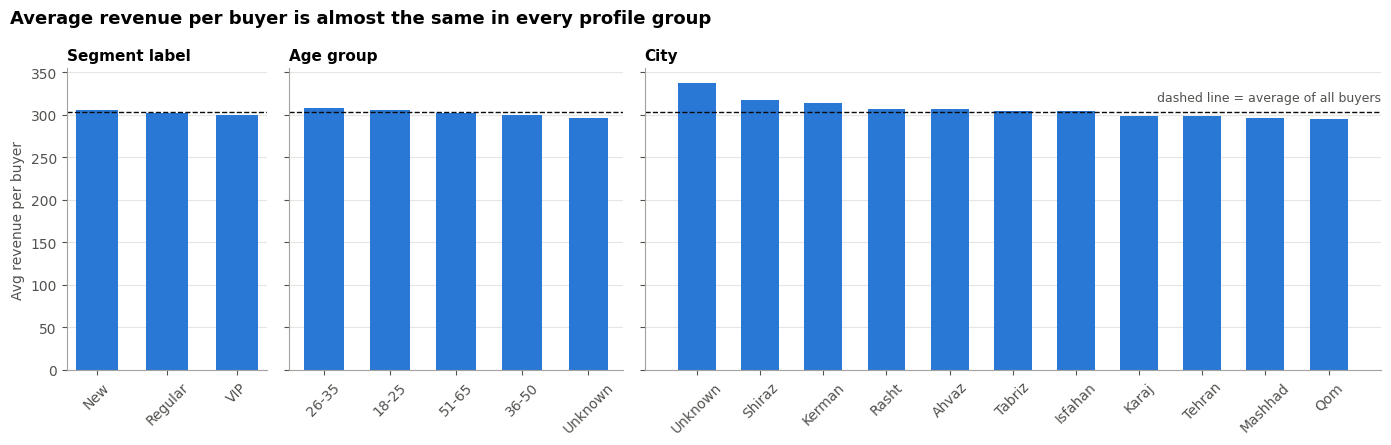

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, gridspec_kw={'width_ratios': [3, 5, 11]})
panel_titles = {'CustomerSegment': 'Segment label', 'Age_Group': 'Age group', 'City': 'City'}
for ax, col in zip(axes, panel_titles):
    values = buyers.groupby(col, observed=True)['Revenue'].mean().sort_values(ascending=False)
    ax.bar(values.index.astype(str), values.values, color=BLUE, width=0.6)
    ax.axhline(buyers['Revenue'].mean(), color=INK, linestyle='--', linewidth=1)
    ax.set_title(panel_titles[col], fontsize=11)
    ax.tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Avg revenue per buyer')
axes[-1].annotate('dashed line = average of all buyers', (1, buyers['Revenue'].mean()),
                  xycoords=('axes fraction', 'data'), xytext=(0, 8), textcoords='offset points',
                  ha='right', fontsize=9, color=MUTED)
fig.suptitle('Average revenue per buyer is almost the same in every profile group',
             x=0.01, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Do profile groups buy different things? Share of each group's revenue by category**

In [155]:
# (buyer_orders already contains each order's customer segment and age group)
for col in ['CustomerSegment', 'Age_Group', 'City']:
    category_share = pd.crosstab(buyer_orders[col], buyer_orders['Category'],
                                 values=buyer_orders['RealizedRevenue'], aggfunc='sum',
                                 normalize='index') * 100
    _, p_cat, _, _ = stats.chi2_contingency(pd.crosstab(buyer_orders[col], buyer_orders['Category']))
    print(f"\n{col}: chi-square p = {p_cat:.2f} (based on number of orders per category) "
          f"({'groups buy different categories' if p_cat < 0.05 else 'all groups buy the same mix of categories'})")
    display(category_share.round(1))


CustomerSegment: chi-square p = 0.45 (based on number of orders per category) (all groups buy the same mix of categories)


Category,Accessories,Electronics,Gaming,Home Office,Stationery,Wearables
CustomerSegment,,,,,,
Guest,NaN,NaN,NaN,NaN,NaN,NaN
New,16.3,51.4,5.9,12.3,1.9,12.3
Regular,15.9,50.1,5.6,13.6,1.9,12.9
VIP,16.8,50.2,6.8,12.8,1.9,11.5



Age_Group: chi-square p = 0.85 (based on number of orders per category) (all groups buy the same mix of categories)


Category,Accessories,Electronics,Gaming,Home Office,Stationery,Wearables
Age_Group,,,,,,
Unknown,16.9,49.4,4.9,15.3,1.5,12.0
18-25,16.3,52.2,6.3,11.9,1.9,11.5
26-35,15.5,50.3,5.7,14.1,1.9,12.4
36-50,16.1,50.7,5.6,12.6,2.0,12.9
51-65,16.5,49.7,5.9,13.2,1.9,12.8
Guest,NaN,NaN,NaN,NaN,NaN,NaN



City: chi-square p = 0.55 (based on number of orders per category) (all groups buy the same mix of categories)


Category,Accessories,Electronics,Gaming,Home Office,Stationery,Wearables
City,,,,,,
Ahvaz,15.8,52.6,5.8,11.7,1.8,12.3
Guest,NaN,NaN,NaN,NaN,NaN,NaN
Isfahan,17.2,47.8,5.6,14.1,2.1,13.3
Karaj,15.1,50.5,6.6,12.6,2.0,13.1
Kerman,17.8,50.5,5.4,12.7,2.1,11.6
Mashhad,15.8,51.2,5.3,12.7,1.9,13.0
Qom,15.3,51.2,6.1,11.8,1.7,13.8
Rasht,16.3,47.6,6.7,14.1,1.9,13.4
Shiraz,15.6,52.6,4.9,13.2,2.0,11.6


In [156]:
# Permutation test: do groups split their REVENUE differently across categories?
# (chi-square above uses order counts; this checks the revenue split shown in the table directly)

# Step 1: revenue per customer per category (one row per customer)
customer_category_revenue = buyer_orders.pivot_table(index='CustomerID', columns='Category',
                                                     values='RealizedRevenue', aggfunc='sum', fill_value=0)

def revenue_split_difference(labels):
    """Total distance between each group's revenue split and the overall split (bigger = groups differ more)."""
    by_group = customer_category_revenue.groupby(labels).sum()
    group_split = by_group.div(by_group.sum(axis=1), axis=0)
    overall_split = by_group.sum() / by_group.values.sum()
    return (group_split - overall_split).abs().sum().sum()

rng = np.random.default_rng(42)   # fixed seed so the result is repeatable
for col in ['CustomerSegment', 'Age_Group']:
    labels = (buyer_orders.drop_duplicates('CustomerID').set_index('CustomerID')[col]
              .reindex(customer_category_revenue.index).astype(str))
    actual = revenue_split_difference(labels.values)
    # Step 2: shuffle the group labels across customers 2,000 times
    shuffled = [revenue_split_difference(rng.permutation(labels.values)) for _ in range(2000)]
    # Step 3: p-value = share of shuffles at least as different as the real data
    p_perm = (np.sum(np.array(shuffled) >= actual) + 1) / (len(shuffled) + 1)
    print(f"{col}: permutation test on revenue split, p = {p_perm:.2f} "
          f"({'groups spend differently across categories' if p_perm < 0.05 else 'all groups split their spending the same way'})")

/tmp/ipykernel_1394/2503873959.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  customer_category_revenue = buyer_orders.pivot_table(index='CustomerID', columns='Category',


CustomerSegment: permutation test on revenue split, p = 0.29 (all groups split their spending the same way)
Age_Group: permutation test on revenue split, p = 0.57 (all groups split their spending the same way)


The chi-square test compares the number of orders per category, since chi-square only works on counts. To check the revenue split shown in the table directly, a permutation test was also run (shuffling group labels across customers 2,000 times). Both tests agree: segment labels and age groups split their spending across categories the same way (chi-square p = 0.45 and 0.85; permutation p = 0.29 and 0.57).

**Overall Finding - customer profile:** Our buyers are mostly Regular-labelled (56%), aged 36-65 (61%), and based in Tehran (28%) and Mashhad (13%). But **no profile group is more valuable than another**: revenue per customer, number of orders and revenue per order are the same across segment labels, age groups and cities (all adjusted p > 0.1), and every group buys the same mix of categories. Each group's share of revenue simply equals its share of customers.

**The VIP label does not identify valuable customers:** VIP customers spend about the same as everyone else (296 per customer vs 298-300 for Regular and New). Profile data alone cannot tell the business who to focus on, so the next step groups customers by **behaviour** instead.

**Behaviour groups (RFM): score every buyer from 1 to 5 on:**
- Recency   : how recently they last bought (5 = most recent 20% of buyers)
- Frequency : how many orders they placed  (5 = top 20% by number of orders)
- Monetary  : how much revenue they brought (5 = top 20% by revenue)

*rank(method='first') breaks ties so each score holds 20% of buyers*

In [157]:
def score_1_to_5(values, higher_is_better=True):
    ranks = values.rank(method='first', ascending=higher_is_better)
    return pd.qcut(ranks, 5, labels=[1, 2, 3, 4, 5]).astype(int)

buyers['RecencyScore'] = score_1_to_5(buyers['DaysSinceLastOrder'], higher_is_better=False)   # fewer days = better
buyers['FrequencyScore'] = score_1_to_5(buyers['Orders'])
buyers['MonetaryScore'] = score_1_to_5(buyers['Revenue'])

def behaviour_group(r, f):
    if r >= 4 and f >= 4: return 'Champions'         # bought recently and often
    if r >= 3 and f >= 3: return 'Loyal'             # fairly recent, buy regularly
    if r <= 2 and f >= 3: return 'At risk'           # used to buy often, but not recently
    if r >= 4 and f <= 2: return 'Promising'         # bought recently, but only a few times
    if r <= 2 and f <= 2: return 'Hibernating'       # few orders, long ago
    return 'Needs attention'                         # middle recency, few orders

buyers['BehaviourGroup'] = [behaviour_group(r, f) for r, f in zip(buyers['RecencyScore'], buyers['FrequencyScore'])]

group_order = ['Champions', 'Loyal', 'At risk', 'Promising', 'Needs attention', 'Hibernating']
behaviour_summary = (buyers.groupby('BehaviourGroup')
                     .agg(Customers=('Orders', 'size'),
                          AvgOrdersPerCustomer=('Orders', 'mean'),
                          AvgRevenuePerCustomer=('Revenue', 'mean'),
                          TotalRevenue=('Revenue', 'sum'),
                          AvgRevenuePerOrder=('AvgRevenuePerOrder', 'mean'),
                          AvgDaysSinceLastOrder=('DaysSinceLastOrder', 'mean'),
                          AvgCategoriesBought=('CategoriesBought', 'mean'))
                     .reindex(group_order))
behaviour_summary['CustomerShare%'] = behaviour_summary['Customers'] / behaviour_summary['Customers'].sum() * 100
behaviour_summary['RevenueShare%'] = behaviour_summary['TotalRevenue'] / behaviour_summary['TotalRevenue'].sum() * 100
behaviour_summary.round(1)

,Customers,AvgOrdersPerCustomer,AvgRevenuePerCustomer,TotalRevenue,AvgRevenuePerOrder,AvgDaysSinceLastOrder,AvgCategoriesBought,CustomerShare%,RevenueShare%
BehaviourGroup,,,,,,,,,
Champions,2121,6.5,454.7,964366.9,69.9,65.7,3.3,21.5,32.3
Loyal,2128,5.0,351.0,746910.7,70.2,142.2,2.9,21.6,25.0
At risk,1666,5.2,356.5,593939.0,69.4,341.4,2.9,16.9,19.9
Promising,1009,2.7,190.7,192460.4,71.4,72.8,2.0,10.2,6.4
Needs attention,657,2.6,184.8,121383.4,70.5,189.2,2.0,6.7,4.1
Hibernating,2277,2.3,162.2,369319.4,70.2,456.7,1.8,23.1,12.4


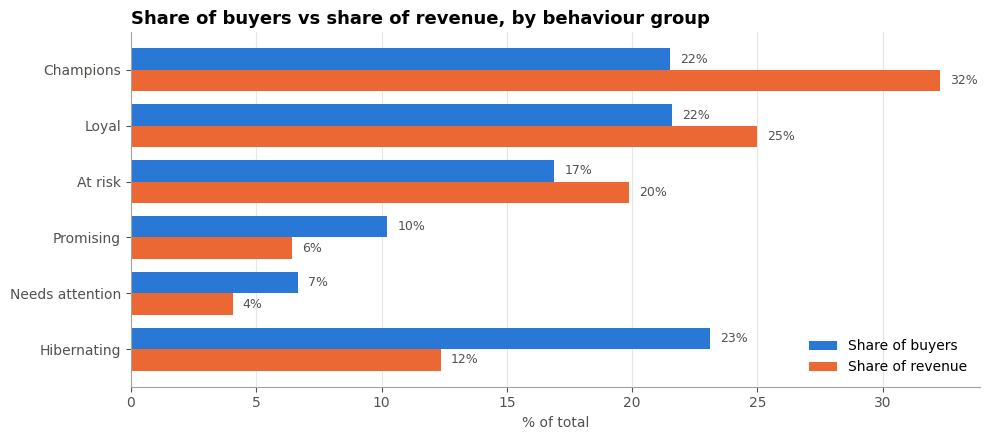

In [140]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = behaviour_summary.index[::-1]   # first group at the top
y = np.arange(len(order))
h = 0.38

ax.barh(y + h/2, behaviour_summary.loc[order, 'CustomerShare%'], height=h, color=BLUE, label='Share of buyers')
ax.barh(y - h/2, behaviour_summary.loc[order, 'RevenueShare%'], height=h, color=ORANGE, label='Share of revenue')
for i, grp in enumerate(order):
    ax.text(behaviour_summary.loc[grp, 'CustomerShare%'] + 0.4, i + h/2,
            f"{behaviour_summary.loc[grp, 'CustomerShare%']:.0f}%", va='center', fontsize=9, color=MUTED)
    ax.text(behaviour_summary.loc[grp, 'RevenueShare%'] + 0.4, i - h/2,
            f"{behaviour_summary.loc[grp, 'RevenueShare%']:.0f}%", va='center', fontsize=9, color=MUTED)

ax.set_yticks(y, order)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('% of total')
ax.set_title('Share of buyers vs share of revenue, by behaviour group')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Finding - behaviour groups:** Grouping buyers by how recently and how often they buy separates them clearly, unlike profile labels.

- **Champions** (22% of buyers) bring in **32% of revenue**: ~6.5 orders and ~455 each, last order ~2 months ago.
- **Loyal** (22%) bring in 25%: ~5 orders and ~351 each.
- **At risk** (17%) brought in **20% of revenue** (~5 orders, ~357 each), similar to Loyal customers, but have not bought for ~11 months on average.
- **Promising** (10%) and **Needs attention** (7%) bought only ~2-3 times and bring in 6% and 4% of revenue.
- **Hibernating** (23%) are the largest group but bring in only 12% of revenue (~2 orders, ~162 each, last order over a year ago).

Revenue per order is about the same in every group (~70), so the difference in value comes from **how often** customers buy, not how much they spend per order. Champions, Loyal and At-risk customers together are 61% of buyers but bring in 77% of revenue.

**Do profiles such as the customer segment,age, or city match real buying behaviour?**


In [158]:
# Do the segment labels, age groups or cities match real buying behaviour?
# Each table: % of buyers in each profile group that fall into each behaviour group (rows add up to 100%)
behaviour_tests = []
for col in ['CustomerSegment', 'Age_Group', 'City']:
    profile_vs_behaviour = pd.crosstab(buyers[col], buyers['BehaviourGroup'],
                                       normalize='index')[group_order] * 100
    print(f"\n{col}")
    display(profile_vs_behaviour.round(1))

    _, p_b, _, _ = stats.chi2_contingency(pd.crosstab(buyers[col], buyers['BehaviourGroup']))
    behaviour_tests.append({'Profile': col, 'p': p_b})

# Adjust for running 3 tests
# (saved under a new name so the behaviour_tests list is not overwritten if the cell is re-run)
behaviour_test_results = pd.DataFrame(behaviour_tests)
behaviour_test_results['AdjustedP'] = stats.false_discovery_control(behaviour_test_results['p'])
behaviour_test_results['Result'] = np.where(behaviour_test_results['AdjustedP'] < 0.05,
                                            'Behaviour differs by profile', 'Behaviour does not depend on profile')
display(behaviour_test_results.round(3))


CustomerSegment


BehaviourGroup,Champions,Loyal,At risk,Promising,Needs attention,Hibernating
CustomerSegment,,,,,,
New,21.3,22.1,16.6,10.9,6.3,22.8
Regular,21.4,21.4,16.9,9.8,6.9,23.5
VIP,22.9,20.7,17.9,10.4,6.4,21.7



Age_Group


BehaviourGroup,Champions,Loyal,At risk,Promising,Needs attention,Hibernating
Age_Group,,,,,,
Unknown,21.8,20.1,14.5,12.8,5.0,25.7
18-25,22.0,23.2,16.0,10.6,6.1,22.1
26-35,19.9,23.2,16.6,9.9,7.5,22.8
36-50,21.8,20.8,17.7,10.2,6.5,23.1
51-65,22.0,20.5,16.9,10.2,6.7,23.8



City


BehaviourGroup,Champions,Loyal,At risk,Promising,Needs attention,Hibernating
City,,,,,,
Ahvaz,20.4,22.8,17.1,12.4,6.7,20.6
Isfahan,24.6,22.5,15.8,8.8,5.6,22.7
Karaj,19.2,20.0,18.6,11.5,6.6,24.1
Kerman,24.7,24.3,14.2,7.2,6.6,23.0
Mashhad,20.6,21.2,15.7,10.8,8.1,23.5
Qom,21.6,22.2,14.9,8.6,7.3,25.4
Rasht,21.4,23.4,17.6,11.7,7.0,18.9
Shiraz,22.3,23.1,17.3,8.3,4.9,24.2
Tabriz,20.1,21.2,17.9,10.5,7.1,23.2


,Profile,p,AdjustedP,Result
0,CustomerSegment,0.633,0.633,Behaviour does not depend on profile
1,Age_Group,0.436,0.633,Behaviour does not depend on profile
2,City,0.020,0.060,Behaviour does not depend on profile


**Finding - do profile labels match behaviour?** No. Each segment label has almost the same mix of behaviour groups: about 21-23% Champions, 17-18% At risk and 22-24% Hibernating, whether the customer is labelled New, Regular or VIP. VIP customers are no more likely to be Champions (22.9%) than New (21.3%) or Regular (21.4%) customers.

Chi-square tests confirm that behaviour group does not depend on segment label (adjusted p = 0.63) or age group (adjusted p = 0.63). City shows a weak hint of a difference (p = 0.02), but it is not significant after adjusting for the three tests (adjusted p = 0.06).

**Implication:** profile fields cannot be used to identify the most valuable customers. The current VIP label in particular does not reflect how customers actually buy, so targeting should be based on the behaviour groups instead.

**Who to focus on: size, value and recommended action for each behaviour group**

In [142]:
actions = {
    'Champions':       'Retain: loyalty rewards, early access to new products; no discounts needed',
    'Loyal':           'Grow: cross-sell other categories and premium products',
    'At risk':         'Win back: personalised re-engagement campaign before they are lost',
    'Promising':       'Nurture: welcome series and second-purchase incentive to build the habit',
    'Needs attention': 'Re-activate: reminders and recommendations based on past purchases',
    'Hibernating':     'Low priority: low-cost automated emails only',
}
focus = behaviour_summary[['Customers', 'CustomerShare%', 'RevenueShare%', 'AvgRevenuePerCustomer',
                           'AvgDaysSinceLastOrder', 'AvgCategoriesBought']].copy()
focus['RecommendedAction'] = focus.index.map(actions)
display(focus.round(1))

at_risk = buyers[buyers['BehaviourGroup'] == 'At risk']
print(f"At-risk customers: {len(at_risk):,}, brought in {at_risk['Revenue'].sum():,.0f} "
      f"({at_risk['Revenue'].sum() / buyers['Revenue'].sum():.0%} of all revenue); "
      f"last order on average {at_risk['DaysSinceLastOrder'].mean():.0f} days ago")
print(f"Last order of at-risk customers, by quarter:")
print(at_risk['LastOrder'].dt.to_period('Q').value_counts().sort_index())

,Customers,CustomerShare%,RevenueShare%,AvgRevenuePerCustomer,AvgDaysSinceLastOrder,AvgCategoriesBought,RecommendedAction
BehaviourGroup,,,,,,,
Champions,2121,21.5,32.3,454.7,65.7,3.3,"Retain: loyalty rewards, early access to new p..."
Loyal,2128,21.6,25.0,351.0,142.2,2.9,Grow: cross-sell other categories and premium ...
At risk,1666,16.9,19.9,356.5,341.4,2.9,Win back: personalised re-engagement campaign ...
Promising,1009,10.2,6.4,190.7,72.8,2.0,Nurture: welcome series and second-purchase in...
Needs attention,657,6.7,4.1,184.8,189.2,2.0,Re-activate: reminders and recommendations bas...
Hibernating,2277,23.1,12.4,162.2,456.7,1.8,Low priority: low-cost automated emails only


At-risk customers: 1,666, brought in 593,939 (20% of all revenue); last order on average 341 days ago
Last order of at-risk customers, by quarter:
LastOrder
2024Q2      2
2024Q3     19
2024Q4     55
2025Q1    134
2025Q2    305
2025Q3    677
2025Q4    474
Freq: Q-DEC, Name: count, dtype: int64


**Conclusion - Objective 4:**

1. **Who our buyers are:** 9,858 of 10,000 registered customers have bought at least once. They are mostly Regular-labelled (56%), aged 36-65 (61%), and based in Tehran (28%) and Mashhad (13%). A typical buyer placed ~4 orders worth ~300 in total over the 2.5 years.
2. **Profile does not predict value:** revenue per customer, order frequency, revenue per order and category mix are the same across segment labels, age groups and cities (all adjusted p > 0.1; the small difference in orders per customer between cities, p = 0.013, is not significant after adjusting for 9 tests). **The VIP label does not identify valuable customers** as VIPs spend the same as other customers and are no more likely to be Champions (23% vs 21%).
3. **Behaviour does predict value:** grouping customers by how recently and how often they buy separates them clearly:
   - **Champions** (22% of buyers) bring in **32% of revenue**, ~455 each.
   - **Loyal** (22%) bring in 25%.
   - **At risk** (17%) brought in **20% of revenue** (~357 each) but have not bought for ~11 months on average; most last bought in mid-to-late 2025.
   - **Promising** (10%) bought recently but only ~3 times.
   - **Hibernating** (23%) bring in only 12%.

**Who the business should focus on:**
- **1st - Win back At-risk customers:** they are proven high-value buyers (~5 orders and ~357 revenue each on average) who have not bought for almost a year. Re-activating even a quarter of them would bring back customers worth ~150K in past revenue. It is also worth checking whether the February 2026 order drop is linked to customers like these going quiet.
- **2nd - Retain Champions:** a third of revenue comes from a fifth of buyers. Keep them with loyalty rewards and early access rather than discounts (Objective 5 showed discounts do not increase units bought).
- **3rd - Nurture Promising customers:** recent buyers with few orders; a second- and third-purchase programme turns them into Loyal customers.
- **Grow Loyal customers through cross-selling:** they buy from ~3 of 6 categories, leaving room to introduce Home Office and Wearables, which bring in about twice their share of orders in revenue (Objective 2).
- **Replace the New / Regular / VIP labels** with behaviour-based groups for targeting, since the current labels do not reflect how customers actually buy.

## Discount Effectiveness

In [107]:
# Discounts are the only source of price variation within a product.
# EffectivePrice = the price the customer actually paid per unit after the discount
realized['PricePaidPerUnit'] = realized['UnitPrice'] * (1 - realized['Discount'])

# For each product: list price, lowest price actually paid, and how far below list price that is
price_range = (realized.groupby('ProductName', observed=True)
               .agg(ListPrice=('UnitPrice', 'first'),
                    LowestPricePaid=('PricePaidPerUnit', 'min'),
                    DiscountLevels=('Discount', 'nunique')))
price_range['MaxReduction%'] = (1 - price_range['LowestPricePaid'] / price_range['ListPrice']) * 100
display(price_range.sort_values('ListPrice', ascending=False).round(2))

print(f"Within each product, the price paid varies by up to "
      f"{price_range['MaxReduction%'].max():.0f}% below list price "
      f"(discount levels used: {sorted(realized['Discount'].unique().tolist())})")

,ListPrice,LowestPricePaid,DiscountLevels,MaxReduction%
ProductName,,,,
Tablet,260.0,182.0,6,30.0
Office Chair,180.0,126.0,6,30.0
Smart Watch,120.0,84.0,6,30.0
Microphone,85.0,59.5,6,30.0
Headphones,75.0,52.5,6,30.0
Gaming Controller,68.0,47.6,6,30.0
Mechanical Keyboard,62.0,43.4,6,30.0
Bluetooth Speaker,58.0,40.6,6,30.0
Fitness Band,55.0,38.5,6,30.0


Within each product, the price paid varies by up to 30% below list price (discount levels used: [0.0, 0.05, 0.1, 0.15, 0.2, 0.3])


From the analysis above, it seems that all product has the same discounting model, where discount varies between 0% - 30% in 6 different levels (0,5,10,15,20,30).

**Units and revenue by discount level**

In [109]:
disc = (realized.groupby('Discount')
        .agg(Orders=('OrderID', 'size'),
             UnitsPerOrder=('Quantity', 'mean'),
             FullPriceValue=('GrossRevenue', 'mean'),
             PaidValue=('RealizedRevenue', 'mean'),
             ))
disc['UnitsPerOrder'] = disc['UnitsPerOrder'].astype(float)
disc['DiscountImpact_toRevenue%'] = (disc['PaidValue'] / disc.loc[0.0, 'PaidValue'] - 1) * 100
display(disc.round(3))

# Do customers buy more units when the discount is bigger?
_, p_units = stats.kruskal(*[g['Quantity'].astype(float).values for _, g in realized.groupby('Discount')])
print(f"Is there a significant difference in number of units purchased per order by discount level? Kruskal-Wallis p = {p_units:.3f}")

,Orders,UnitsPerOrder,FullPriceValue,PaidValue,DiscountImpact_toRevenue%
Discount,,,,,
0.00,15061,1.873,74.594,74.594,0.0
0.05,9331,1.898,75.386,71.617,-3.991
0.10,8463,1.890,76.565,68.909,-7.622
0.15,5128,1.882,76.441,64.975,-12.895
0.20,3062,1.871,76.727,61.381,-17.713
0.30,1676,1.881,80.192,56.134,-24.747


Is there a significant difference in number of units purchased per order by discount level? Kruskal-Wallis p = 0.560


In [113]:
# Do discounted customers buy more expensive products?
by_discount = realized.groupby('Discount')

price_check = by_discount.agg(AvgProductPrice=('UnitPrice', 'mean'),
                              FullPriceValue=('GrossRevenue', 'mean'))
# percentage of product with price > 100
price_check['PremiumShare%'] = by_discount['UnitPrice'].apply(lambda s: (s > 100).mean() * 100)
display(price_check.round(2))

# 1. Average product price
_, p_price = stats.kruskal(*[g['UnitPrice'].values for _, g in by_discount])
# 2. Order value before discount
_, p_value = stats.kruskal(*[g['GrossRevenue'].astype(float).values for _, g in by_discount])
# 3. Share of premium products (unit price above 100)
_, p_premium, _, _ = stats.chi2_contingency(pd.crosstab(realized['Discount'], realized['UnitPrice'] > 100))

print(f"Is there a significant difference in Average product price by discount level:        Kruskal-Wallis p = {p_price:.2f}")
print(f"Is there a significant difference in Full Price value (No Discount Revenue/order) by discount level:  Kruskal-Wallis p = {p_value:.2f}")
print(f"Is there a significant difference in Share of premium products by discount level:    chi-square p = {p_premium:.2f}")

,AvgProductPrice,FullPriceValue,PremiumShare%
Discount,,,
0.00,39.99,74.59,5.79
0.05,39.98,75.39,5.83
0.10,40.38,76.57,5.88
0.15,41.01,76.44,6.05
0.20,40.67,76.73,6.34
0.30,41.83,80.19,6.68


Is there a significant difference in Average product price by discount level:        Kruskal-Wallis p = 0.66
Is there a significant difference in Full Price value (No Discount Revenue/order) by discount level:  Kruskal-Wallis p = 0.72
Is there a significant difference in Share of premium products by discount level:    chi-square p = 0.63


The analysis result above indicates that discount highly impacts the net revenue received, reducing revenue per order by over 24% for 30% discount. However,  it does not seem to impact the number of purchases made, nor does it increase the number of premium/expensive purchases.

Discounted customers do not buy more expensive products: average product price, full price value and the share of premium items show no significant difference across discount levels (all p > 0.1).

The 30% discount group has a slightly higher full price value (80.19 vs 74.59) because its orders happened to include slightly pricier products, while units per order are the same (~1.9). This difference is not statistically significant and reflects random variation in a smaller group (1,676 orders), not customers choosing more expensive items because of the discount.


**Does a bigger discount lead customers to buy more units per order in some categories or products, even if not overall?**

*Note on method:* The number of orders at each discount level only shows how often each discount was given, so it cannot measure the discount's effect. Instead, each group is tested for whether **units per order** rise as the discount rises (Spearman correlation). Because 6 categories and 20 products are tested, some results will look significant by chance; p-values are therefore adjusted for multiple testing (Benjamini-Hochberg). A group is only called significant if its **adjusted p-value** is below 0.05.

*Category results*

In [118]:
def discount_effect_by(level):
    """For each group: do customers buy more units per order when the discount is bigger?"""
    rows = []
    for name, g in realized.groupby(level, observed=True):
        units = g['Quantity'].astype(float)
        corr = stats.spearmanr(g['Discount'], units)
        rows.append({
            level: name,
            'Orders': len(g),
            'AvgUnits_NoDiscount': units[g['Discount'] == 0].mean(),
            'AvgUnits_20PlusDiscount': units[g['Discount'] >= 0.20].mean(),
            'Correlation': corr.statistic,
            'p': corr.pvalue,
        })
    table = pd.DataFrame(rows).set_index(level)
    table['UnitsChange%'] = (table['AvgUnits_20PlusDiscount'] / table['AvgUnits_NoDiscount'] - 1) * 100
    # Adjust p-values for testing many groups at once (Benjamini-Hochberg)
    table['AdjustedP'] = stats.false_discovery_control(table['p'])
    table['Verdict'] = np.select(
        [(table['AdjustedP'] < 0.05) & (table['Correlation'] > 0),
         (table['AdjustedP'] < 0.05) & (table['Correlation'] < 0),
         table['p'] < 0.05],
        ['Discount increases units',
         'Discount decreases units',
         'Possible signal - not significant after adjustment'],
        default='No significant effect')
    cols = ['Orders', 'AvgUnits_NoDiscount', 'AvgUnits_20PlusDiscount', 'UnitsChange%',
            'Correlation', 'p', 'AdjustedP', 'Verdict']
    return table[cols].sort_values('Correlation', ascending=False)

print("By category")
display(discount_effect_by('Category').round(3))

By category


,Orders,AvgUnits_NoDiscount,AvgUnits_20PlusDiscount,UnitsChange%,Correlation,p,AdjustedP,Verdict
Category,,,,,,,,
Home Office,2728,1.881,1.891,0.508,0.027,0.166,0.872,No significant effect
Stationery,4660,1.886,1.872,-0.757,0.005,0.744,0.872,No significant effect
Wearables,2666,1.912,1.997,4.454,0.004,0.850,0.872,No significant effect
Accessories,15769,1.889,1.889,-0.041,0.003,0.704,0.872,No significant effect
Electronics,15445,1.842,1.830,-0.661,0.001,0.872,0.872,No significant effect
Gaming,1453,1.888,1.935,2.494,-0.019,0.479,0.872,No significant effect


*Product results (and Chart of units per order, no discount vs 20–30% discount)*

In [119]:
print("By product")
discount_by_product = discount_effect_by('ProductName')
display(discount_by_product.round(3))

By product


,Orders,AvgUnits_NoDiscount,AvgUnits_20PlusDiscount,UnitsChange%,Correlation,p,AdjustedP,Verdict
ProductName,,,,,,,,
Tablet,552,1.701,2.179,28.101,0.118,0.006,0.114,Possible signal - not significant after adjust...
Desk Lamp,1822,1.853,1.930,4.199,0.048,0.041,0.408,Possible signal - not significant after adjust...
Smart Watch,1072,1.876,2.080,10.840,0.034,0.260,0.868,No significant effect
Bluetooth Speaker,1834,1.851,1.861,0.543,0.019,0.419,0.868,No significant effect
Microphone,1360,1.877,1.789,-4.673,0.015,0.568,0.868,No significant effect
Monitor,686,1.458,1.493,2.410,0.012,0.747,0.906,No significant effect
Phone Case,4301,1.895,1.966,3.762,0.010,0.520,0.868,No significant effect
USB-C Cable,4070,1.901,1.888,-0.709,0.009,0.554,0.868,No significant effect
HDMI Cable,3381,1.891,1.902,0.570,0.009,0.607,0.868,No significant effect


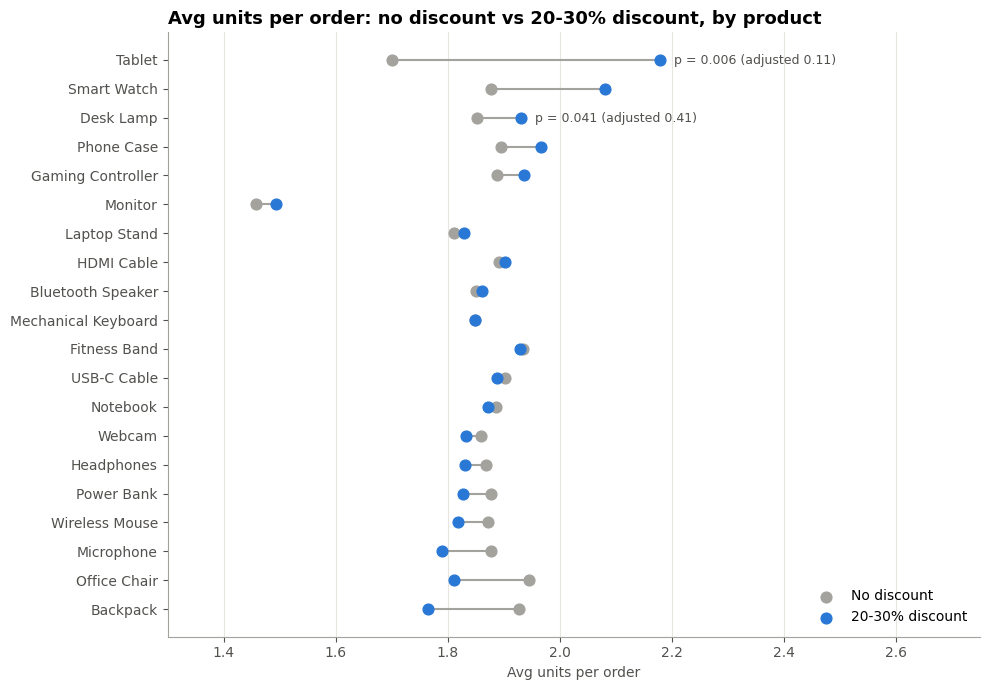

In [120]:
chart_data = discount_by_product.sort_values('UnitsChange%')
y = np.arange(len(chart_data))

fig, ax = plt.subplots(figsize=(10, 7))
ax.hlines(y, chart_data['AvgUnits_NoDiscount'], chart_data['AvgUnits_20PlusDiscount'], color=GREY, linewidth=1.5)
ax.scatter(chart_data['AvgUnits_NoDiscount'], y, s=60, color=GREY, zorder=3, label='No discount')
ax.scatter(chart_data['AvgUnits_20PlusDiscount'], y, s=60, color=BLUE, zorder=3, label='20-30% discount')

# mark products with a possible signal
for i, (name, r) in enumerate(chart_data.iterrows()):
    if r['p'] < 0.05:
        ax.annotate(f"p = {r['p']:.3f} (adjusted {r['AdjustedP']:.2f})",
                    (max(r['AvgUnits_NoDiscount'], r['AvgUnits_20PlusDiscount']), i),
                    textcoords='offset points', xytext=(10, -3), fontsize=9, color=MUTED)

ax.set_yticks(y, chart_data.index)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('Avg units per order')
ax.set_xlim(1.3, 2.75)
ax.set_title('Avg units per order: no discount vs 20-30% discount, by product')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

*Tablet product close-up*

In [124]:
tablet = realized[realized['ProductName'] == 'Tablet']
tablet_by_discount = (tablet.groupby('Discount')
                      .agg(Orders=('OrderID', 'size'),
                           AvgUnitsPerOrder=('Quantity', 'mean'),
                           AvgRevenuePerOrder=('RealizedRevenue', 'mean'))
                      .astype(float))
tablet_by_discount['DiscountImpact_toRevenue%'] = (tablet_by_discount['AvgRevenuePerOrder']
                                                      / tablet_by_discount.loc[0.0, 'AvgRevenuePerOrder'] - 1) * 100
tablet_by_discount.round(2)

,Orders,AvgUnitsPerOrder,AvgRevenuePerOrder,DiscountImpact_toRevenue%
Discount,,,,
0.00,184.0,1.70,442.28,0.00
0.05,117.0,1.95,481.33,8.83
0.10,98.0,1.87,436.96,-1.20
0.15,86.0,1.83,403.45,-8.78
0.20,38.0,2.03,421.47,-4.70
0.30,29.0,2.38,433.03,-2.09


**Findings - discount effect by category and product:**

1. No category responds to discounts. units per order do not rise with the discount in any of the 6 categories (all p > 0.16).
2. No product responds significantly after adjusting for multiple tests. Two products looked significant on their own: Tablet (p = 0.006) and Desk Lamp (p = 0.041). After adjusting for testing 20 products, neither is significant (adjusted p = 0.11 and 0.41). With 20 tests, about one false positive is expected by chance.
3. Tablet is worth a closer look, but not a conclusion. units per order rise from 1.70 with no discount to 2.38 at 30% off. However, the 30% group has only 29 orders, and revenue per order is no higher than at full price, because the extra units only offset the discount.


**Price elasticity within each product**

In [114]:
# Price elasticity: % change in quantity for a 1% change in price, measured WITHIN each product
# (a log-log regression with product fixed effects, done by centring each product on its own mean,
#  so we only compare the same product at different discount levels)
log_q = np.log(realized['Quantity'].astype(float))
log_p = np.log(realized['EffectivePrice'])
y = log_q - log_q.groupby(realized['ProductID']).transform('mean')
x = log_p - log_p.groupby(realized['ProductID']).transform('mean')

elasticity = (x * y).sum() / (x * x).sum()
residuals = y - elasticity * x
dof = len(realized) - realized['ProductID'].nunique() - 1
se = np.sqrt((residuals ** 2).sum() / dof / (x * x).sum())
p_elast = 2 * stats.t.sf(abs(elasticity / se), dof)

print(f"Price elasticity of quantity: {elasticity:.3f} "
      f"(95% CI {elasticity - 1.96*se:.3f} to {elasticity + 1.96*se:.3f}), p = {p_elast:.3f}")

Price elasticity of quantity: -0.007 (95% CI -0.063 to 0.049), p = 0.801


Looking at the elasticity result, it seems that quantity (sales) does not respond to price. While the elasticity value is negative (-0.007) meaning that a price cut lead to slightly higher quantity, it is not statistically significant and can be considered as having no impact.  

**Cost of discounting**

In [115]:
discount_cost = realized['DiscountAmount'].sum()
gross = realized['GrossRevenue'].sum()
print(f"Orders with a discount: {(realized['Discount'] > 0).mean():.0%}")
print(f"Revenue given away as discounts: {discount_cost:,.0f} ({discount_cost / gross:.1%} of gross revenue)")

Orders with a discount: 65%
Revenue given away as discounts: 246,075 (7.6% of gross revenue)


**Do deeper-discount months bring more orders?**

In [116]:
monthly_disc = (realized[realized['OrderDate'] < '2026-01-01']
                .groupby('OrderMonth')
                .agg(AvgDiscount=('Discount', 'mean'), Orders=('OrderID', 'size')))
rho = stats.spearmanr(monthly_disc['AvgDiscount'], monthly_disc['Orders'])
print(f"Months with deeper discounts vs number of orders: Spearman r = {rho.statistic:.2f}, p = {rho.pvalue:.3f}")

Months with deeper discounts vs number of orders: Spearman r = -0.02, p = 0.936


The analysis above shows that there's no significant correlation between number of orders and months with deeper discounts (Spearman r = -0.02, p = 0.94). This means that months where customers received bigger discounts on average did not bring in more orders than other months.

However, this result should be read with caution. The average discount barely changed from month to month (between 7.1% and 7.8% across 2024-2025), so there were no clear "high-discount months" to compare against, and only 24 months of data. This test on its own is therefore weak evidence.

It is still consistent with the stronger order-level results above: discounts do not increase the number of units per order (p = 0.56), and price sensitivity is effectively zero. Together, these suggest discounts are not driving extra sales. To properly test whether larger discounts attract more orders, the business would need to run a controlled experiment, for example an A/B test or a time-limited campaign with a clearly bigger discount.

**Conclusion - Pricing:**

In this analysis, Discounts were used to measure price sensitivity within the same product.

1. **Customers are not price-sensitive to discounts:** units per order stay at ~1.9 across all discount levels (p = 0.56), and the estimated price elasticity is effectively zero (-0.007, 95% CI -0.06 to +0.05).
2. **Discounts reduce revenue per order without increasing volume:** a 30% discount order brings 25% less revenue than a full-price order for the same number of units.
3. **Discounted customers do not choose more expensive products:** average unit price, full-price value per order and the share of premium products are the same at every discount level (all p > 0.6).
4. **The cost is significant:** 65% of orders are discounted, giving away 246K (7.6% of gross revenue) with no measurable lift in units or monthly orders.

**Recommendation:** Reduce blanket discounting, starting with the 20-30% tiers. Because this data cannot show whether discounts attract customers who would not otherwise buy, validate the change with an A/B test (e.g., half of visitors see the current discounts, half see reduced discounts) and compare conversion and revenue per visitor before rolling it out. Furthermore, discounts do not work better in any particular category, so the recommendation to reduce blanket discounts applies across the whole range. If the business wants to keep one targeted discount, Tablet is the best candidate to test in a controlled promotion, measuring revenue and profit per order, not just units.

# Summary of findings and recommendations





## Key findings






**1. Revenue performance**
- Revenue was flat through 2024-2025 at ~105K per month; 2025 was within 0.4% of 2024 (no significant trend).
- From February 2026, revenue dropped ~32% overnight and stayed there. The drop came from fewer orders and fewer active customers, spread evenly across every category, city, segment and payment method; revenue per order did not change.
- There is no monthly seasonal pattern, but there is a weekly one: revenue is 10-13% above average on Saturday and Sunday and lowest mid-week.

**2. Product mix**
- Electronics brings in 51% of revenue from 36% of orders; Accessories has a similar share of orders (37%) but only 16% of revenue.
- Revenue is concentrated: 10 of 20 products bring in 71% of revenue. Headphones, Office Chair and Tablet alone make up 28%.
- Low-priced items (cables, notebook, mouse) bring in 37% of orders but only 10% of revenue.
- Home Office and Wearables bring in about twice their share of orders in revenue.

**3. Lost revenue**
- 14.4% of potential revenue (504K) is lost through orders that were not successful.
- Most of it is a records problem, not lost sales: 53% are refunds owed to customers (cancelled or returned but still marked as paid), 23% are payments not collected on delivered orders, and 20% were refunded after delivery.
- The loss rate is the same across every product, customer group, city and payment method, and stable over time. Customers buy again at the same rate after an unsuccessful order, and there is no group of repeat offenders. The cause is a process issue: order and payment systems are not kept in sync.

**4. Customer value**
- 98.6% of registered customers have bought at least once; a typical buyer placed ~4 orders worth ~300 over 2.5 years.
- Profile does not predict value: buyer rate, spending, order frequency, revenue per order, days between orders and category mix are the same across segment labels, age groups and cities. The VIP label does not identify valuable customers.
- Behaviour does predict value: Champions (22% of buyers) bring in 32% of revenue, while At-risk customers (17% of buyers) brought in 20% of revenue but have not bought for ~11 months.

**5. Discounts**
- 65% of successful orders have a discount, costing 246K (7.6% of full-price value).
- Discounts do not make customers buy more: units per order stay at ~1.9 at every discount level, price sensitivity is effectively zero, and no category or product responds significantly to discounts.
- An order with a 30% discount brings in 25% less revenue than a full-price order with the same number of units.

## Recommendations (in priority order)




1. **Investigate the February 2026 drop with the data and engineering team.** A sudden, even 32% fall across every group points to a technical or channel issue (e.g., a sales channel or data feed that stopped being recorded). Confirm whether it is a real fall in sales before any other decision is based on 2026 figures.
2. **Fix order-payment reconciliation.** Finance should check the 3,711 orders where a refund may be owed; Operations should confirm payment before dispatch; IT/Data should run a daily mismatch report with an owner, targeting a mismatch rate below 1% (currently 14%).
3. **Win back At-risk customers.** 1,666 proven buyers (~5 orders and ~357 revenue each) have gone quiet. Run a personalised re-engagement campaign, and check whether their lapse is linked to the February 2026 drop.
4. **Reduce blanket discounting.** Start with the 20-30% discount levels, which cost the most per order without increasing units. Validate the change with an A/B test before rolling it out, and if a targeted discount is kept, test it on Tablet first.
5. **Retain Champions without discounts.** Use loyalty rewards and early access to new products for the 22% of buyers who bring in a third of revenue.
6. **Grow order value through the product range.** Protect stock and marketing for the 10 top-revenue products, bundle low-priced items (cables, cases) with higher-priced ones, and cross-sell Home Office and Wearables to Loyal customers, who currently buy from about 3 of 6 categories.
7. **Replace the New / Regular / VIP labels with behaviour groups** (Champions, Loyal, At risk, Promising, Needs attention, Hibernating) for all customer targeting.
8. **Time campaigns for the weekend.** Schedule promotions and emails for Friday-Sunday, when customers are most active.

## Data limitations


- Signup dates are unreliable (28% of orders are dated before the customer's signup), so signup-based measures were not used.
- Each product has one fixed price and there is no cost data, so profit and full price optimisation could not be analysed.
- Monitor's unit price (21) looks incorrect and should be verified.
- Several patterns (identical behaviour across all groups, a Saturday-Sunday peak in an Iranian market where the weekend is Thursday-Friday) suggest the dataset may be synthetic; findings are framed as what they would mean for a real business.

# Export Clean Dataset


Build the clean tables and save them to Drive and the repo folder

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/Analytics Portfolio/clean_data'
REPO_DIR = '/content/Sales-Analysis'
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f'{REPO_DIR}/clean', exist_ok=True)

# Star schema: one fact table + two dimension tables (ready for SQL / Power BI)
fact_orders = finaldf.drop(columns=['CustomerSegment', 'Age', 'Age_Group', 'City',
                                    'ProductName', 'Category'])
dim_customers = customers[['CustomerID', 'Age', 'Age_Group', 'City_cleaned',
                           'SignupDate', 'CustomerSegment']].rename(columns={'City_cleaned': 'City'})
dim_products = products.copy()

tables = {'fact_orders': fact_orders, 'dim_customers': dim_customers, 'dim_products': dim_products}
for name, df in tables.items():
    df.to_csv(f'{DRIVE_DIR}/{name}.csv', index=False)          # permanent copy in Drive
    df.to_csv(f'{REPO_DIR}/clean/{name}.csv', index=False)     # copy inside the GitHub repo folder
    print(f"Saved {name}: {len(df):,} rows")

Commit and push the clean tables to github

In [ ]:
# Commit the clean tables to GitHub
# Requires a GitHub token saved in Colab Secrets as GITHUB_TOKEN (see setup steps below)
from google.colab import userdata
import subprocess

token = userdata.get('GITHUB_TOKEN')
repo_url = f'https://{token}@github.com/celynhs/Sales-Analysis.git'

def git(*args):
    """Run a git command in the repo and print its output with the token hidden."""
    r = subprocess.run(['git', '-C', REPO_DIR, *args], capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, '***').strip()
    if out:
        print(out)
    return r.returncode

git('config', 'user.name', 'Jocelin Helsa')
git('config', 'user.email', 'YOUR_GITHUB_EMAIL')   # the email on your GitHub account

git('pull', '--rebase', repo_url, 'main')          # get any changes made on GitHub first
git('add', 'clean/')
if git('diff', '--cached', '--quiet') == 0:
    print('No changes to commit - clean tables are already up to date.')
else:
    git('commit', '-m', 'Update cleaned star-schema tables (fact_orders, dim_customers, dim_products)')
    git('push', repo_url, 'HEAD:main')